# Лабораторная работа 3. Анализ ЭКГ сигналов

Егорова Варвара, 408575

Ташкинова Татьяна, 413084

Аббясов Радислам, 367038


## Импорт и просмотр данных

In [ ]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import neurokit2 as nk

plt.rcParams["figure.figsize"] = (15, 4)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving walk_EEG.dat to walk_EEG.dat
Saving after_run5_EEG.dat to after_run5_EEG.dat
Saving after_run1_EEG.dat to after_run1_EEG.dat
Saving run1_EEG.dat to run1_EEG.dat
Saving run5_EEG.dat to run5_EEG.dat
Saving after_walk_EEG.dat to after_walk_EEG.dat
Saving calm_EEG.dat to calm_EEG.dat


In [ ]:
files = list(uploaded.keys())

print("Загруженные файлы:")
for f in files:
    print(f)

Загруженные файлы:
walk_EEG.dat
after_run5_EEG.dat
after_run1_EEG.dat
run1_EEG.dat
run5_EEG.dat
after_walk_EEG.dat
calm_EEG.dat


In [ ]:
def load_signal(filename):

    with open(filename, "r") as f:
        text = f.read()

    text = text.replace("\n", " ").replace(",", " ")

    values = np.array([float(v) for v in text.split()])

    if len(values) % 2 != 0:
        values = values[:-1]

    values = values.reshape(-1, 2)

    time = values[:, 0]
    signal = values[:, 1]

    return time, signal

In [ ]:
signals = {}
fs = None

for file in files:

    time, signal = load_signal(file)

    signals[file] = {
        "time": time,
        "signal": signal,
        "duration": time[-1] - time[0]
    }

    if fs is None:
      time_diff = np.diff(time)
      avg_interval = np.mean(time_diff)
      fs = int(round(1 / avg_interval))
      print(f"Частота выборки: {fs} Hz")

    print(f"\nФайл: {file}")

    print("Размер сигнала:", len(signal))

    print("Первые значения сигнала:")
    print(signal[:10])

    print(f"Продолжительность: {signals[file]["duration"]}")

    print("Минимум:", np.min(signal))
    print("Максимум:", np.max(signal))

Частота выборки: 320 Hz

Файл: walk_EEG.dat
Размер сигнала: 97903
Первые значения сигнала:
[4.96078444 4.96078444 4.96078444 4.96078444 4.96078444 4.96078444
 4.96078444 4.96078444 4.96078444 4.96078444]
Продолжительность: 306.26489258000004
Минимум: 0.7647059
Максимум: 4.98039198

Файл: after_run5_EEG.dat
Размер сигнала: 103289
Первые значения сигнала:
[2.52941179 2.29411769 2.2352941  2.41176462 2.62745094 2.60784316
 2.33333325 2.15686274 2.15686274 2.37254906]
Продолжительность: 323.06445312999995
Минимум: 0.60784316
Максимум: 4.98039198

Файл: after_run1_EEG.dat
Размер сигнала: 112232
Первые значения сигнала:
[2.47058821 2.47058821 2.47058821 2.47058821 2.47058821 2.47058821
 2.47058821 2.47058821 2.47058821 2.47058821]
Продолжительность: 351.06374359
Минимум: 0.78431374
Максимум: 5.0

Файл: run1_EEG.dat
Размер сигнала: 20023
Первые значения сигнала:
[2.43137264 2.43137264 2.43137264 2.43137264 2.43137264 2.43137264
 2.43137264 2.43137264 2.43137264 2.43137264]
Продолжительность: 

## Аналичитеские функции

In [ ]:
# автоматическое обнаружение R-пиков

def find_r_peaks(signal, sampling_rate, min_interval, peak_threshold):

    min_samples = int(min_interval * sampling_rate)

    median = np.median(signal)
    mad = np.median(np.abs(signal - median))

    threshold = peak_threshold * mad * 1.4826

    peaks, properties = find_peaks(
        signal,
        distance=min_samples,
        prominence=threshold
    )

    peak_times = peaks / sampling_rate

    return peaks, peak_times

In [ ]:
# вычисляет RR-интервалы и ЧСС

def compute_heart_rate(peak_times, rr_min=300, rr_max=1500):

    if len(peak_times) < 2:
        return np.array([]), np.array([])

    rr_intervals = np.diff(peak_times) * 1000

    valid_rr = rr_intervals[
        (rr_intervals >= rr_min) &
        (rr_intervals <= rr_max)
    ]

    bpm = 60000 / valid_rr

    return valid_rr, bpm

In [ ]:
# основные показатели вариабельности сердечного ритма (HRV) на основе RR-интервалов

def get_hrv_statistics(rr_intervals):

    if len(rr_intervals) < 2:
        return {}

    rr = np.array(rr_intervals)

    avg_rr = np.mean(rr)

    avg_bpm = 60000 / avg_rr

    sdnn = np.std(rr)

    rr_diff = np.diff(rr)

    rmssd = np.sqrt(np.mean(rr_diff ** 2))

    nn50 = np.sum(np.abs(rr_diff) > 50)

    pnn50 = (nn50 / len(rr_diff)) * 100

    variation_coef = sdnn / avg_rr

    metrics = {
        "mean_hr_bpm": round(avg_bpm, 1),
        "mean_rr_ms": round(avg_rr, 1),
        "sdnn_ms": round(sdnn, 1),
        "rmssd_ms": round(rmssd, 1),
        "pnn50_percent": round(pnn50, 1),
        "variation_coefficient": round(variation_coef, 3),
        "min_rr_ms": round(np.min(rr), 1),
        "max_rr_ms": round(np.max(rr), 1),
        "rr_spread_ms": round(np.max(rr) - np.min(rr), 1),
        "interval_count": len(rr)
    }

    return metrics

## Вспомогательные функции

In [ ]:
def crop_signal(signal, fs, start_sec=10, end_sec=10):
    start_idx = int(start_sec * fs)
    end_idx = int(len(signal) - end_sec * fs)
    return signal[start_idx:end_idx]

def bandpass_filter(signal, fs, lowcut=0.5, highcut=50, order=6):
    nyquist = fs / 2
    b, a = butter(order, [lowcut/nyquist, highcut/nyquist], btype='band')
    return filtfilt(b, a, signal)

In [ ]:
def visualize_signal(data, sampling_rate, label="Signal", duration_sec=5):

    samples_to_show = int(duration_sec * sampling_rate)

    time = np.arange(samples_to_show) / sampling_rate

    fragment = data[:samples_to_show]

    plt.figure(figsize=(15, 5))

    plt.plot(time, fragment, linewidth=0.7)

    plt.title(f"{label} — first {duration_sec} seconds")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.grid(True, alpha=0.3)

    plt.show()

    total_time = len(data) / sampling_rate

    print(f"\nStatistics for {label}:")

    print(f"Duration: {total_time:.1f} s")
    print(f"Samples count: {len(data)}")

    print(f"Minimum value: {np.min(data):.4f}")
    print(f"Maximum value: {np.max(data):.4f}")

    print(f"Mean value: {np.mean(data):.4f}")
    print(f"Standard deviation: {np.std(data):.4f}")

In [ ]:
def compare_bandpass_filters(signal, fs,
                             low_freq=0.5,
                             high_freq=60,
                             filter_orders=[2, 4, 6],
                             duration_sec=5,
                             signal_name="ECG"):

    samples = int(duration_sec * fs)

    time = np.arange(samples) / fs

    raw_fragment = signal[:samples]

    filtered_versions = []

    for current_order in filter_orders:

        filtered_signal = bandpass_filter(
            signal,
            fs,
            low_freq,
            high_freq,
            current_order
        )

        filtered_versions.append(filtered_signal[:samples])

    fig, axes = plt.subplots(
        len(filter_orders) + 1,
        1,
        figsize=(15, 10)
    )

    axes[0].plot(time, raw_fragment, linewidth=0.5)

    axes[0].set_title("Raw Signal")
    axes[0].set_ylabel("Amplitude")

    axes[0].grid(True, alpha=0.3)

    for idx, (order, filtered) in enumerate(zip(filter_orders, filtered_versions)):

        axes[idx + 1].plot(time, filtered, linewidth=0.7)

        axes[idx + 1].set_title(
            f"Band-pass filter: {low_freq}-{high_freq} Hz | order={order}"
        )

        axes[idx + 1].set_ylabel("Amplitude")

        axes[idx + 1].grid(True, alpha=0.3)

        axes[idx + 1].axhline(
            y=0,
            linestyle="--",
            linewidth=0.6,
            alpha=0.5
        )

    axes[-1].set_xlabel("Time (s)")

    plt.suptitle(
        f"{signal_name} — comparison of filter orders",
        fontsize=14
    )

    plt.tight_layout()

    plt.show()

    # статистика
    print(f"\nFilter comparison ({low_freq}-{high_freq} Hz)")
    print("-" * 45)

    print(f"Raw signal std: {np.std(signal):.4f}")

    for order in filter_orders:

        filtered_full = bandpass_filter(
            signal,
            fs,
            low_freq,
            high_freq,
            order
        )

        print(
            f"order={order}: "
            f"std={np.std(filtered_full):.4f}, "
            f"mean={np.mean(filtered_full):.4f}"
        )

In [ ]:
def show_ecg_peaks(signal,
                   peak_indices,
                   fs,
                   signal_name="ECG",
                   duration_sec=10):

    samples_to_show = int(duration_sec * fs)

    time = np.arange(samples_to_show) / fs

    visible_signal = signal[:samples_to_show]

    visible_peaks = peak_indices[peak_indices < samples_to_show]

    plt.figure(figsize=(15, 4))

    plt.plot(
        time,
        visible_signal,
        linewidth=0.7,
        label="ECG signal"
    )

    plt.scatter(
        visible_peaks / fs,
        signal[visible_peaks],
        s=25,
        zorder=5,
        label=f"Detected peaks: {len(visible_peaks)}"
    )

    plt.title(
        f"{signal_name} — detected R peaks"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

In [ ]:
def show_hrv(rr_intervals,
                  bpm_values,
                  name="HRV Analysis"):

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # RR интервалы
    axes[0, 0].plot(
        rr_intervals,
        'o-',
        linewidth=0.8,
        markersize=3
    )

    axes[0, 0].axhline(
        y=np.mean(rr_intervals),
        linestyle='--',
        label=f"Mean: {np.mean(rr_intervals):.1f} ms"
    )

    axes[0, 0].set_title("RR Interval Series")

    axes[0, 0].set_xlabel("Beat index")
    axes[0, 0].set_ylabel("RR interval (ms)")

    axes[0, 0].legend()

    axes[0, 0].grid(True, alpha=0.3)

    # ЧСС
    axes[0, 1].plot(
        bpm_values,
        'o-',
        linewidth=0.8,
        markersize=3
    )

    axes[0, 1].axhline(
        y=np.mean(bpm_values),
        linestyle='--',
        label=f"Mean: {np.mean(bpm_values):.1f} bpm"
    )

    axes[0, 1].set_title("Heart Rate Series")

    axes[0, 1].set_xlabel("Beat index")
    axes[0, 1].set_ylabel("Heart rate (bpm)")

    axes[0, 1].legend()

    axes[0, 1].grid(True, alpha=0.3)

    # Гистограмма RR
    axes[1, 0].hist(
        rr_intervals,
        bins=np.arange(
        0,
        np.max(rr_intervals) + 50,
        50
    ),
        edgecolor='black',
        alpha=0.7
    )

    axes[1, 0].axvline(
        x=np.mean(rr_intervals),
        linestyle='--',
        label=f"Mean: {np.mean(rr_intervals):.1f} ms"
    )

    axes[1, 0].set_title("RR Interval Distribution")

    axes[1, 0].set_xlabel("RR interval (ms)")
    axes[1, 0].set_ylabel("Count")

    axes[1, 0].legend()

    axes[1, 0].grid(True, alpha=0.3)

    # Poincare plot
    axes[1, 1].scatter(
        rr_intervals[:-1],
        rr_intervals[1:],
        s=15,
        alpha=0.6
    )

    axes[1, 1].set_title("Poincare Plot")

    axes[1, 1].set_xlabel("RR(n) (ms)")
    axes[1, 1].set_ylabel("RR(n+1) (ms)")

    axes[1, 1].grid(True, alpha=0.3)

    min_rr = min(
        np.min(rr_intervals[:-1]),
        np.min(rr_intervals[1:])
    )

    max_rr = max(
        np.max(rr_intervals[:-1]),
        np.max(rr_intervals[1:])
    )

    axes[1, 1].plot(
        [min_rr, max_rr],
        [min_rr, max_rr],
        '--',
        alpha=0.5
    )

    plt.suptitle(name, fontsize=14)

    plt.tight_layout()

    plt.show()

## Предобработка данных

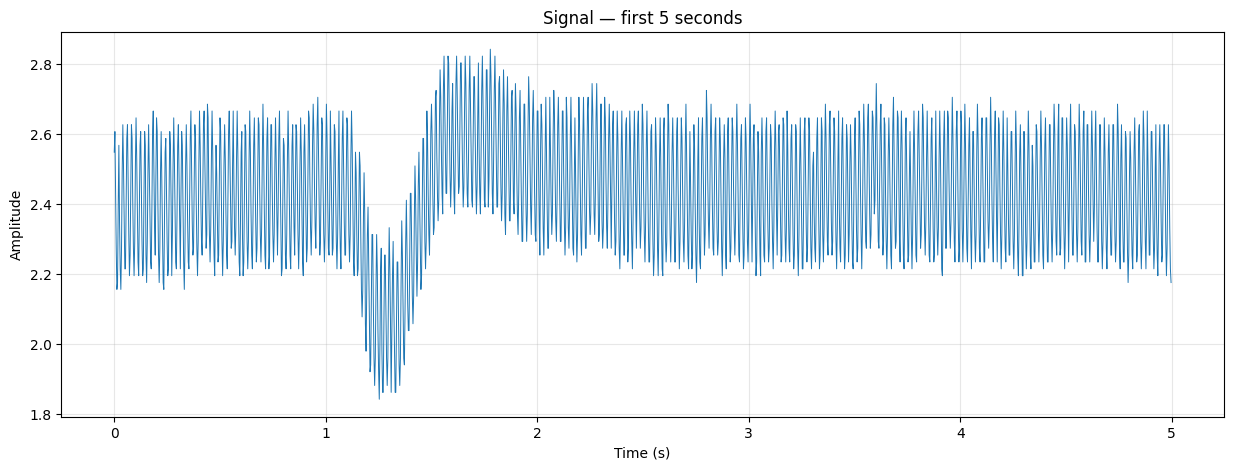


Statistics for Signal:
Duration: 308.0 s
Samples count: 98560
Minimum value: 0.7647
Maximum value: 3.7843
Mean value: 2.4337
Standard deviation: 0.1225


In [ ]:
visualize_signal(signals["calm_EEG.dat"]['signal'], sampling_rate=fs)

In [ ]:
signal_1_calm = crop_signal(signals['calm_EEG.dat']['signal'], fs, start_sec=10, end_sec=10)

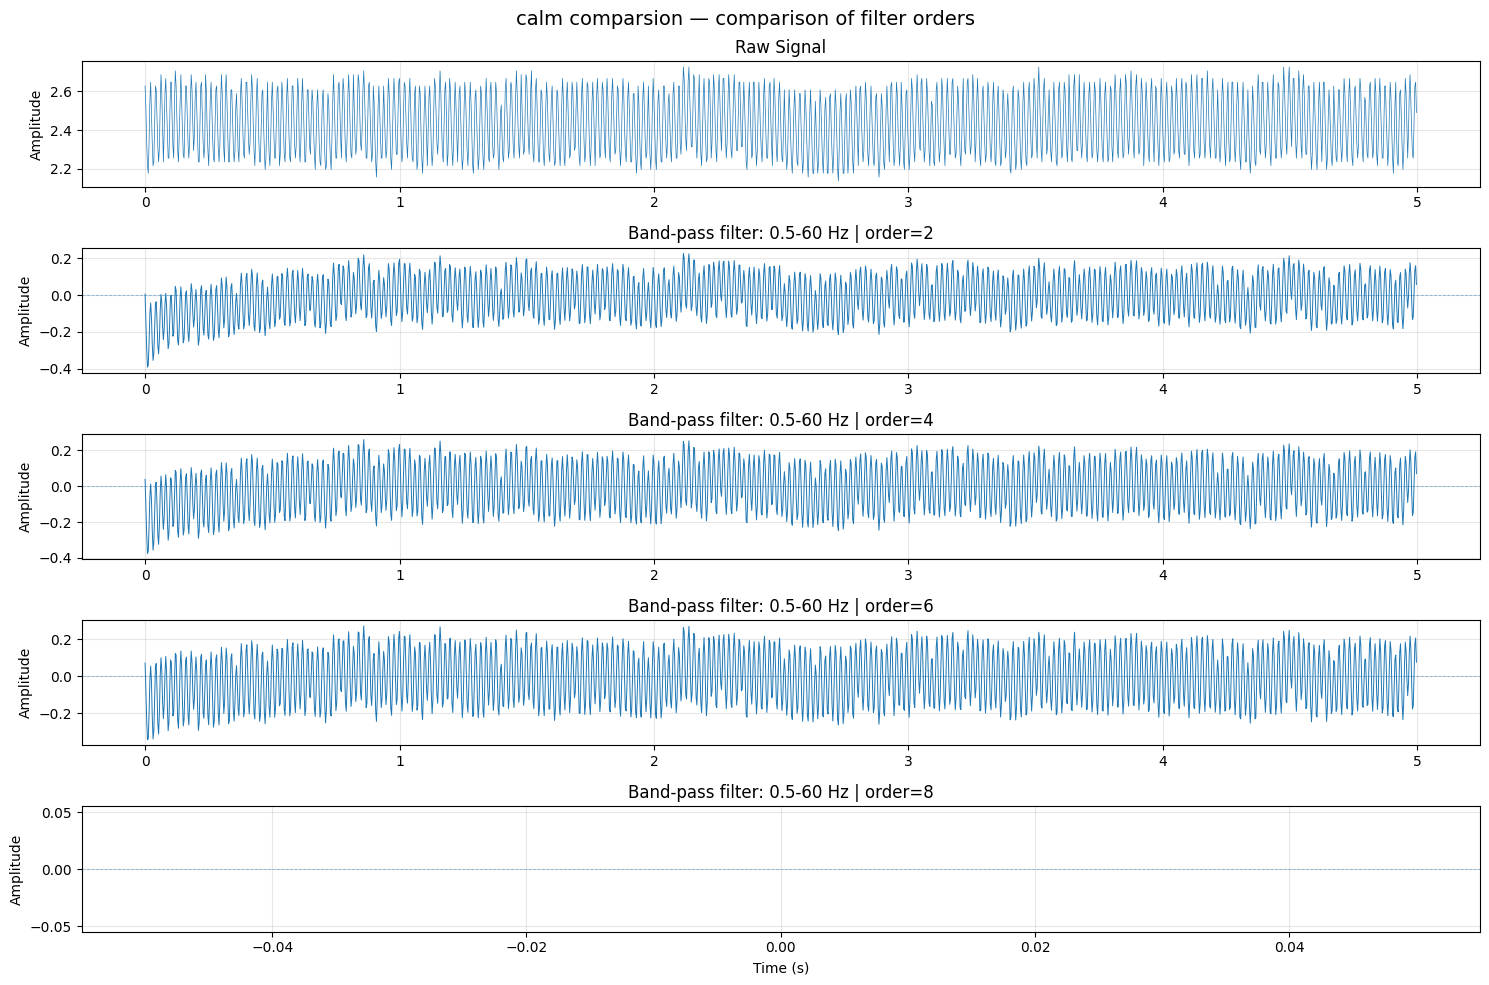


Filter comparison (0.5-60 Hz)
---------------------------------------------
Raw signal std: 0.1217
order=2: std=0.0949, mean=-0.0001
order=4: std=0.1065, mean=-0.0001
order=6: std=0.1128, mean=-0.0001
order=8: std=nan, mean=nan


In [ ]:
compare_bandpass_filters(
    signal=signal_1_calm,
    fs=fs,
    filter_orders=[2, 4, 6, 8],
    signal_name="calm comparsion"
)

Немного смягчим требования и посмотрим на случай когда порядок равен 8.

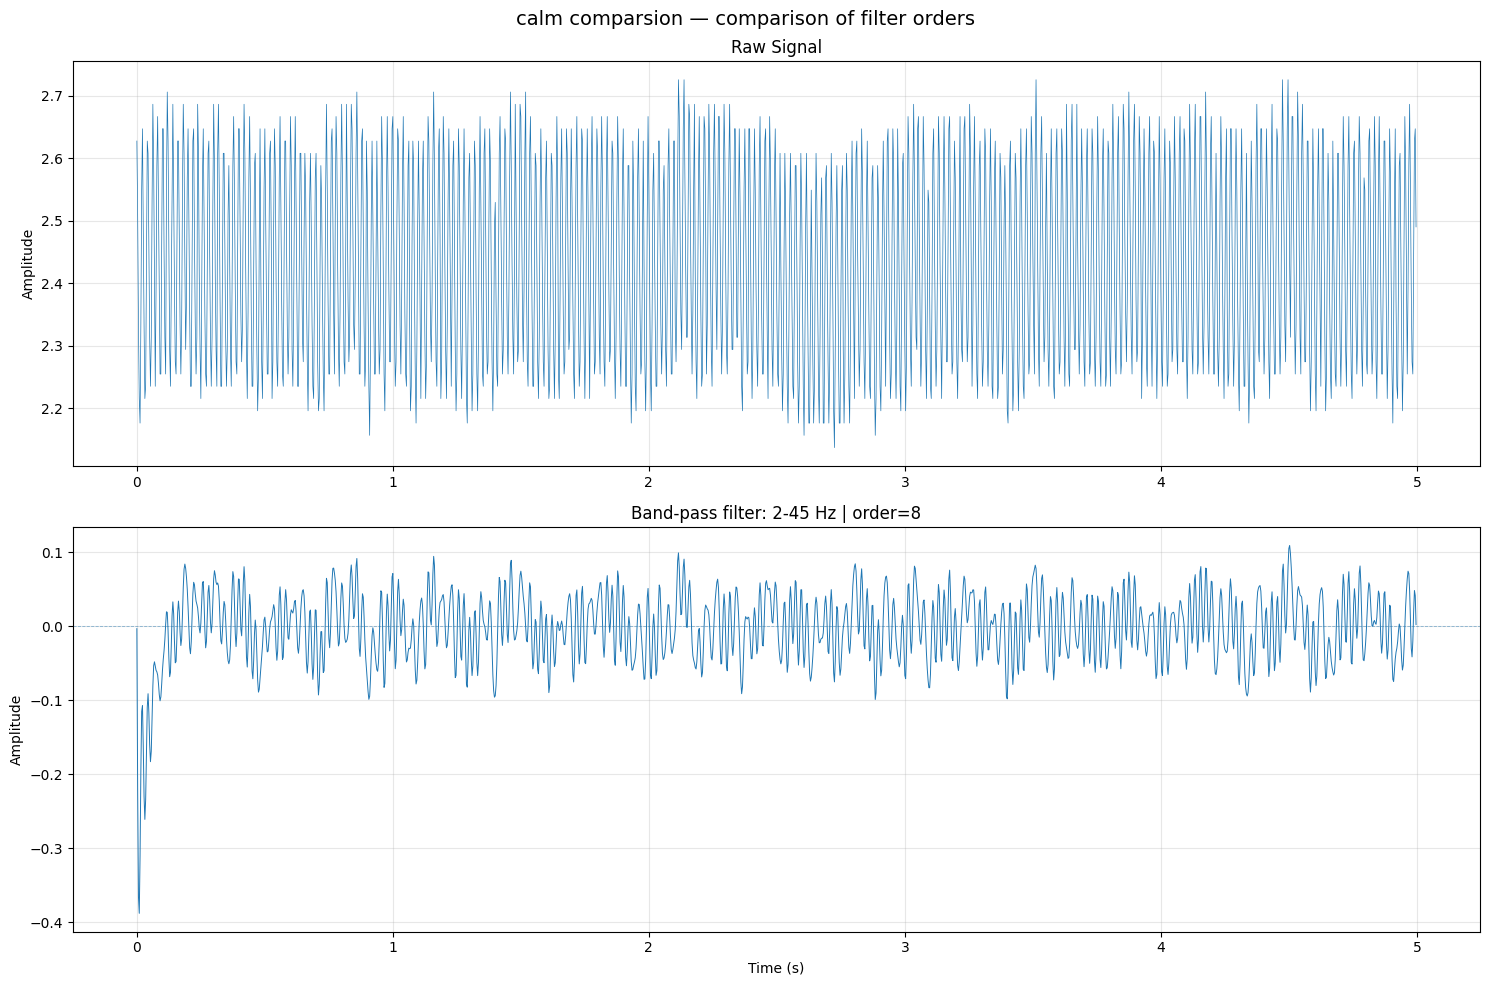


Filter comparison (2-45 Hz)
---------------------------------------------
Raw signal std: 0.1217
order=8: std=0.0526, mean=0.0001


In [ ]:
compare_bandpass_filters(
    signal=signal_1_calm,
    fs=fs,
    low_freq=2,
    high_freq=45,
    filter_orders=[8],
    signal_name="calm comparsion"
)

Все таки, наиболее гладкий сигнал получается при порядке 6

In [ ]:
signal_calm = bandpass_filter(signal_1_calm, fs)

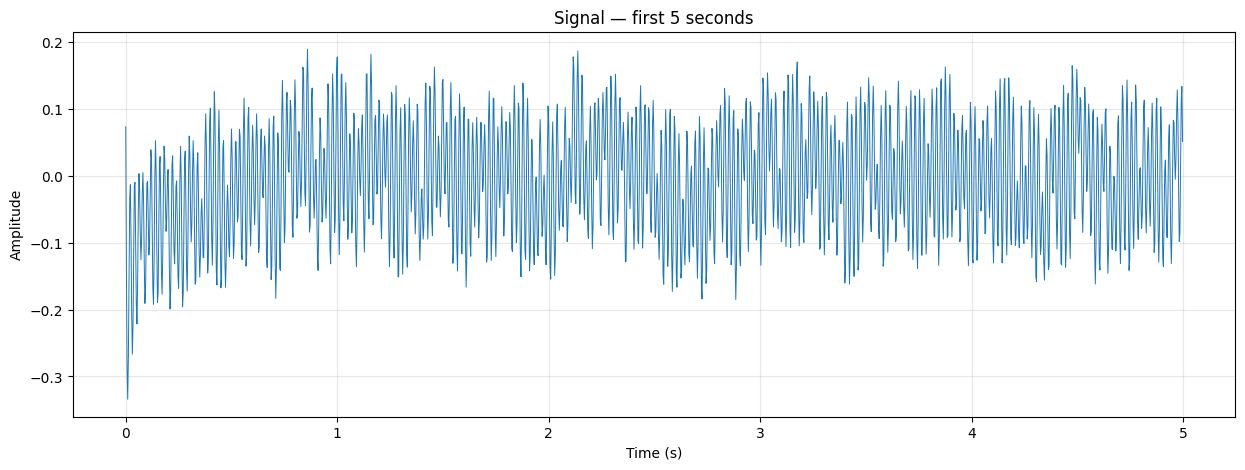


Statistics for Signal:
Duration: 288.0 s
Samples count: 92160
Minimum value: -1.3981
Maximum value: 1.2776
Mean value: -0.0000
Standard deviation: 0.0813


In [ ]:
visualize_signal(signal_calm, fs)

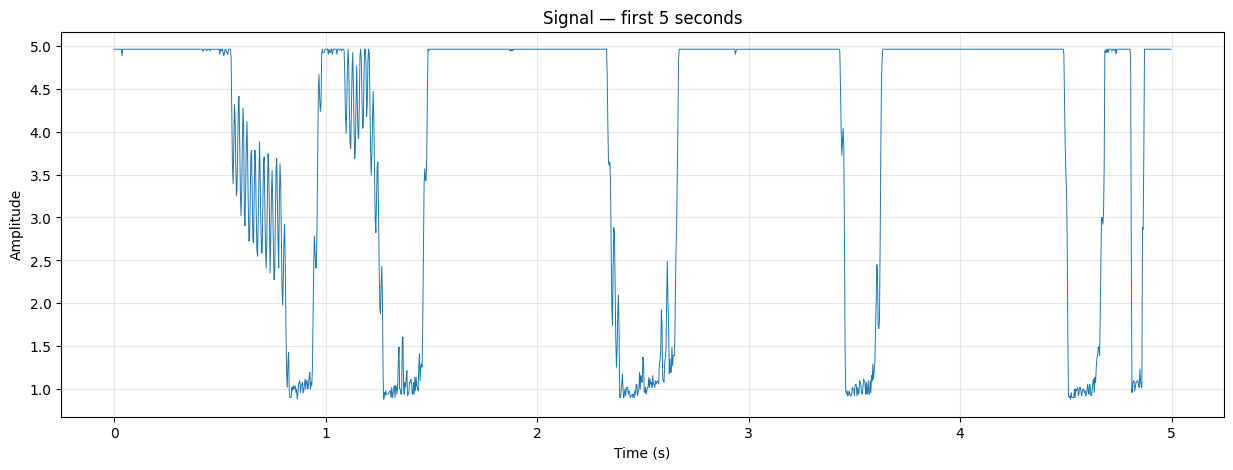


Statistics for Signal:
Duration: 305.9 s
Samples count: 97903
Minimum value: 0.7647
Maximum value: 4.9804
Mean value: 3.4142
Standard deviation: 1.7191


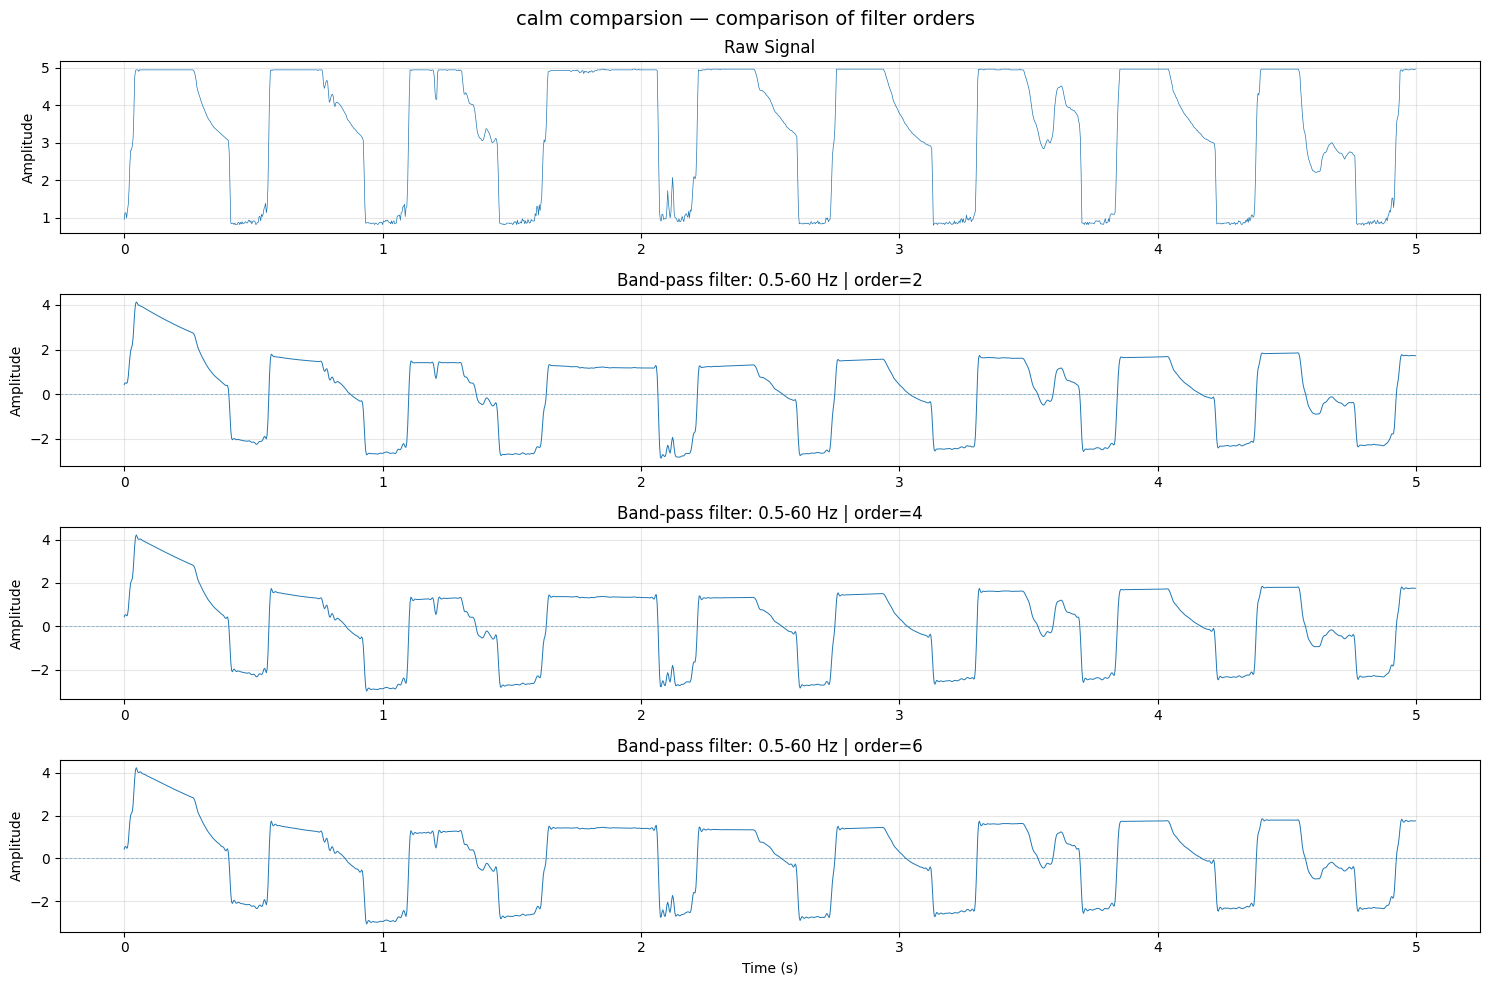


Filter comparison (0.5-60 Hz)
---------------------------------------------
Raw signal std: 1.7309
order=2: std=1.6226, mean=0.0026
order=4: std=1.6327, mean=0.0025
order=6: std=1.6337, mean=0.0027


In [ ]:
visualize_signal(signals['walk_EEG.dat']['signal'], fs)

signal_1_walk = crop_signal(signals['walk_EEG.dat']['signal'], fs, start_sec=10, end_sec=10)

compare_bandpass_filters(
    signal=signal_1_walk,
    fs=fs,
    low_freq=0.5,
    filter_orders=[2, 4, 6],
    signal_name="calm comparsion"
)

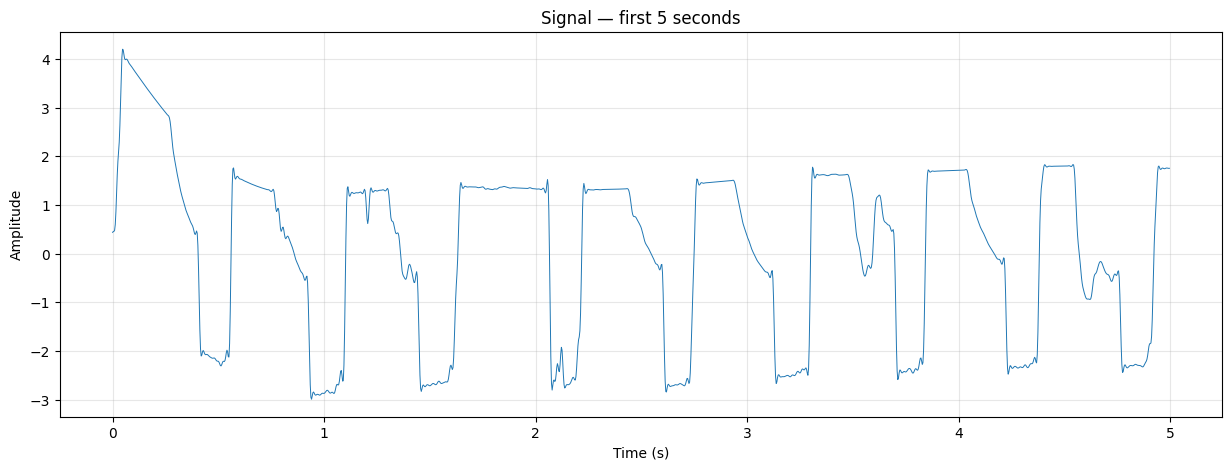


Statistics for Signal:
Duration: 285.9 s
Samples count: 91503
Minimum value: -4.0614
Maximum value: 4.1998
Mean value: 0.0024
Standard deviation: 1.6295


In [ ]:
signal_walk = bandpass_filter(signal_1_walk, fs, order=4)
visualize_signal(signal_walk, fs)

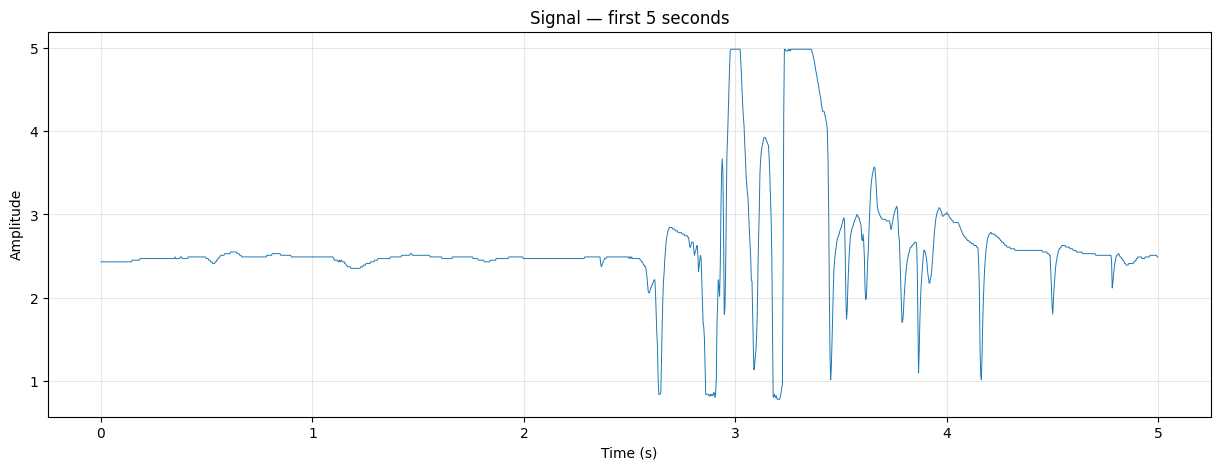


Statistics for Signal:
Duration: 62.6 s
Samples count: 20023
Minimum value: 0.7647
Maximum value: 5.0000
Mean value: 2.8108
Standard deviation: 0.8852


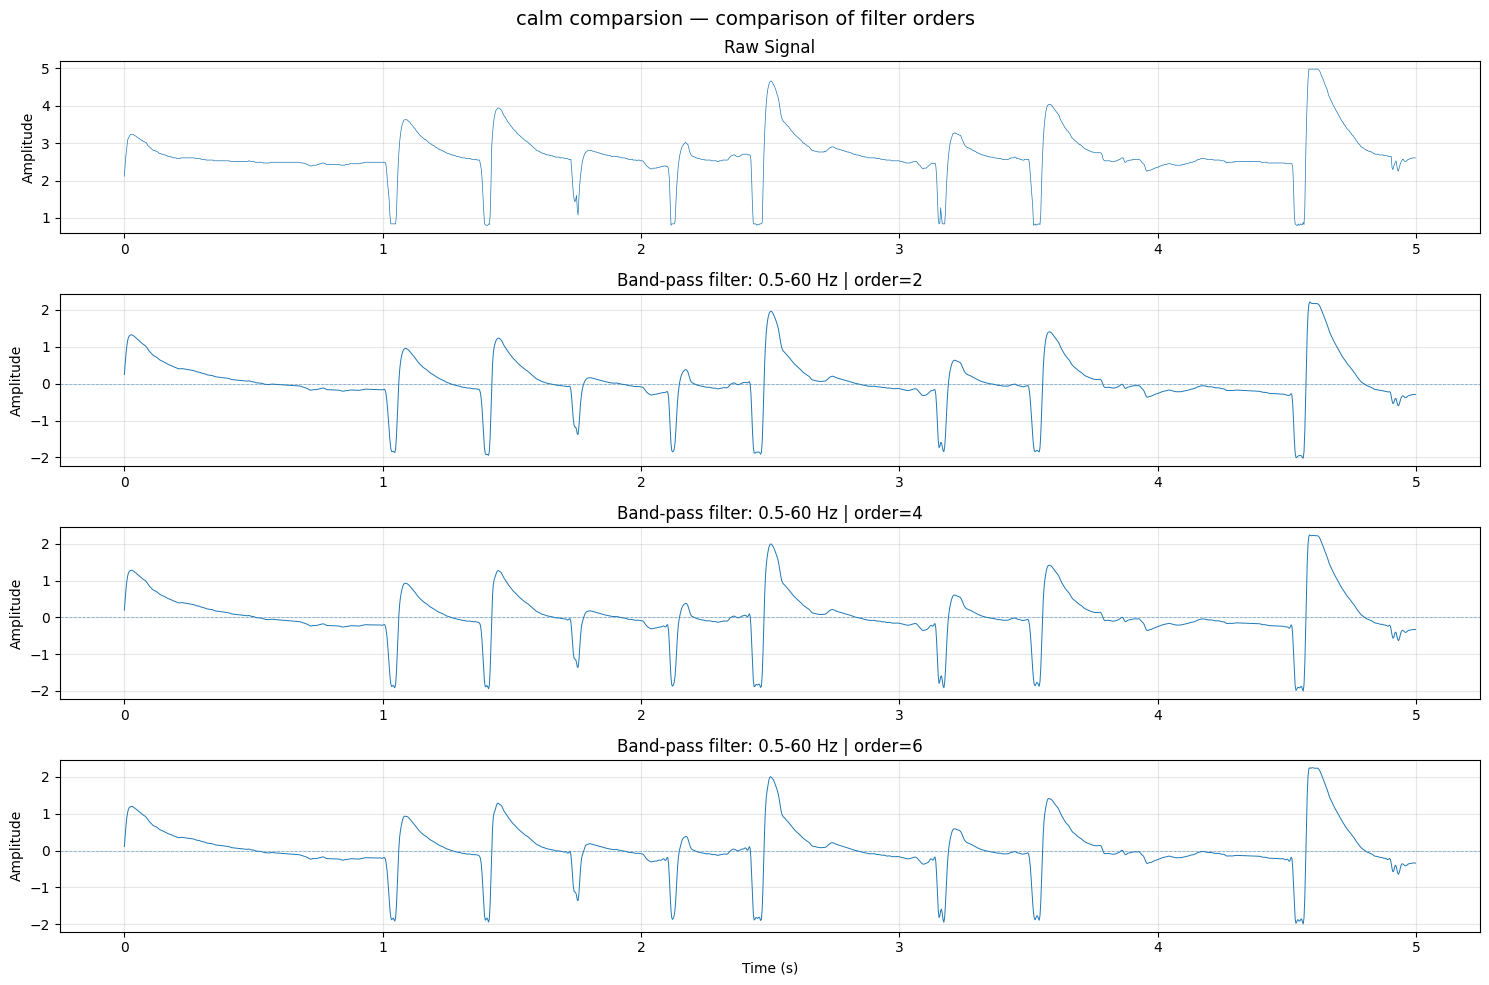


Filter comparison (0.5-60 Hz)
---------------------------------------------
Raw signal std: 0.9342
order=2: std=0.7886, mean=0.0045
order=4: std=0.7951, mean=0.0040
order=6: std=0.7954, mean=0.0041


In [ ]:
visualize_signal(signals['run1_EEG.dat']['signal'], fs)

signal_1_run1 = crop_signal(signals['run1_EEG.dat']['signal'], fs, start_sec=10, end_sec=10)

compare_bandpass_filters(
    signal=signal_1_run1,
    fs=fs,
    filter_orders=[2, 4, 6],
    signal_name="calm comparsion"
)

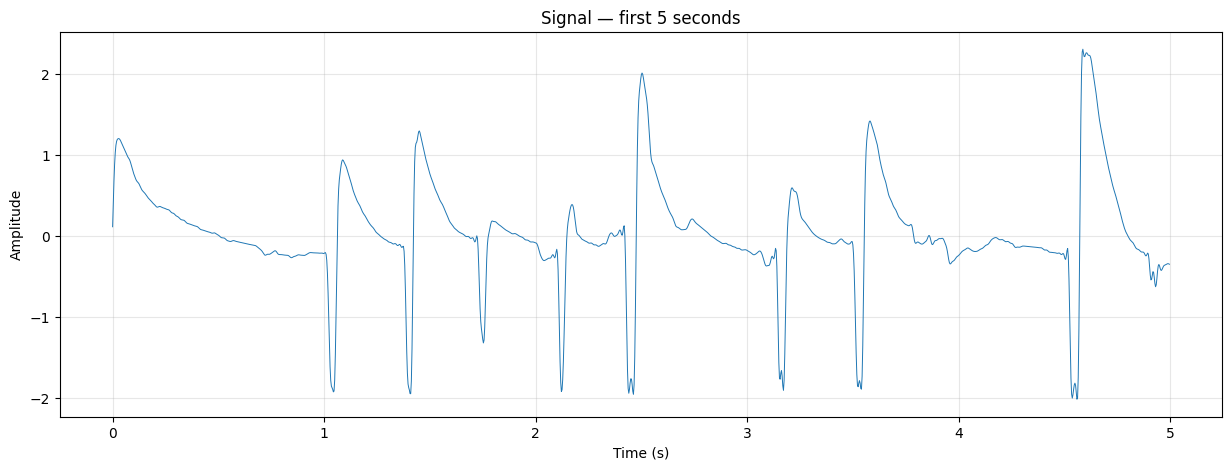


Statistics for Signal:
Duration: 42.6 s
Samples count: 13623
Minimum value: -3.7411
Maximum value: 2.3023
Mean value: 0.0043
Standard deviation: 0.7954


In [ ]:
signal_run1 = bandpass_filter(signal_1_run1, fs)
visualize_signal(signal_run1, fs)

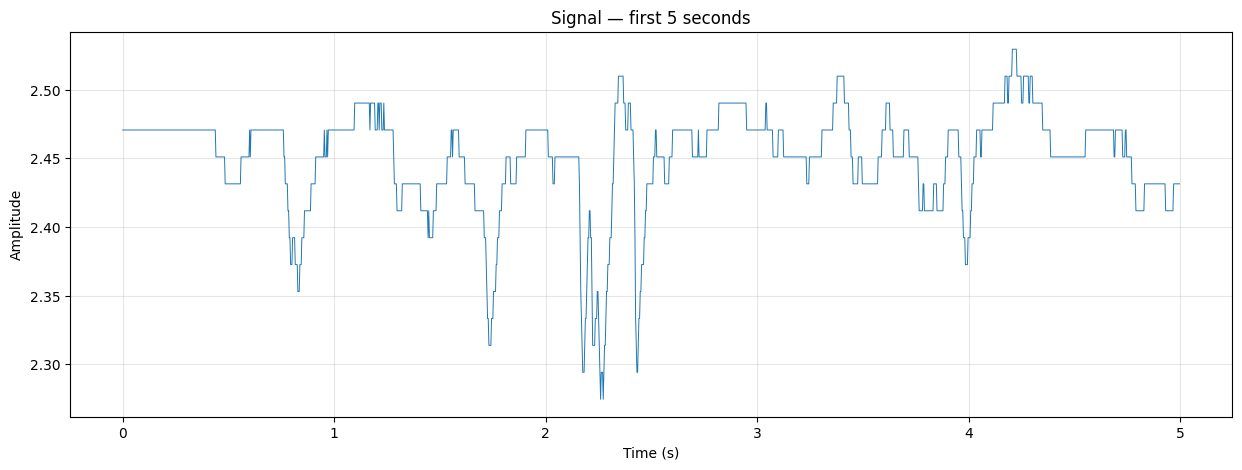


Statistics for Signal:
Duration: 350.7 s
Samples count: 112232
Minimum value: 0.7843
Maximum value: 5.0000
Mean value: 2.4716
Standard deviation: 0.1584


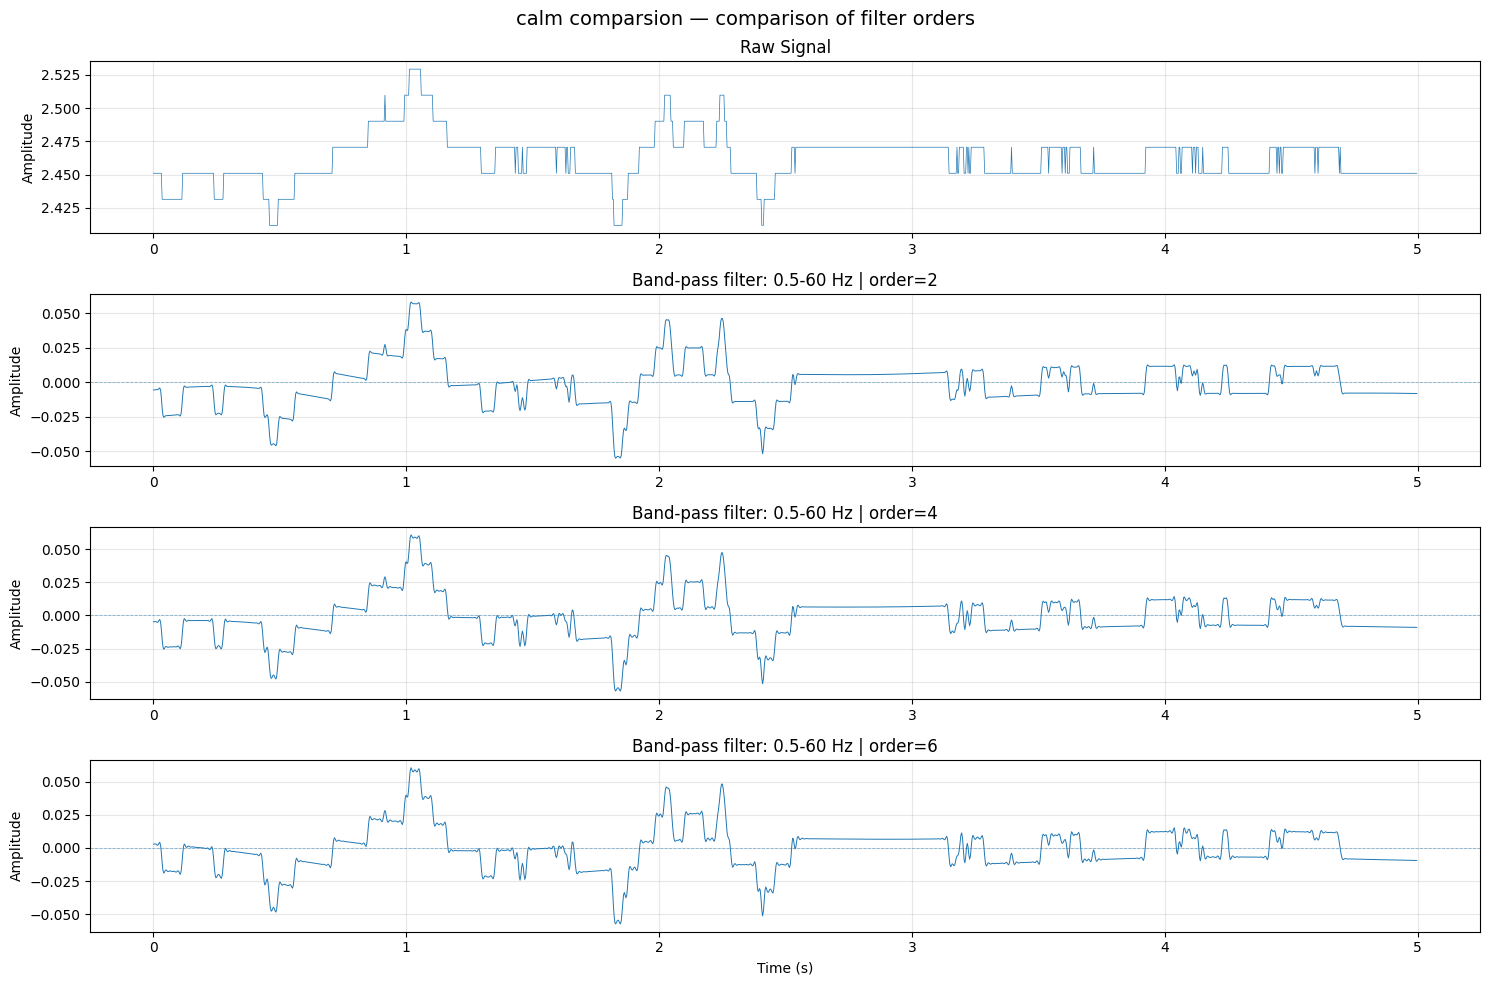


Filter comparison (0.5-60 Hz)
---------------------------------------------
Raw signal std: 0.1630
order=2: std=0.1030, mean=-0.0000
order=4: std=0.1058, mean=-0.0000
order=6: std=0.1068, mean=-0.0000


In [ ]:
visualize_signal(signals['after_run1_EEG.dat']['signal'], fs)

signal_1_after_run1 = crop_signal(signals['after_run1_EEG.dat']['signal'], fs, start_sec=10, end_sec=10)

compare_bandpass_filters(
    signal=signal_1_after_run1,
    fs=fs,
    filter_orders=[2, 4, 6],
    signal_name="calm comparsion"
)

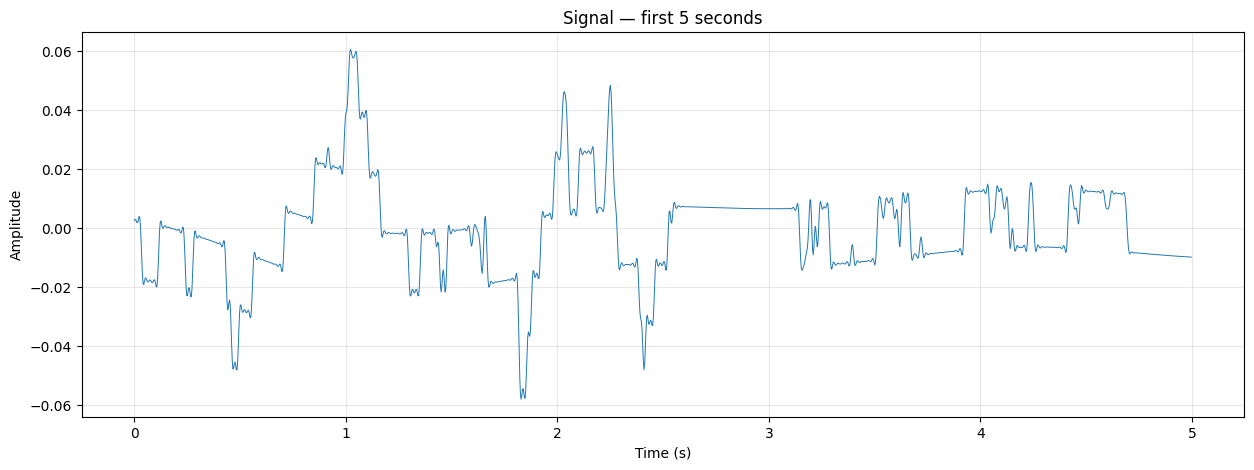


Statistics for Signal:
Duration: 330.7 s
Samples count: 105832
Minimum value: -3.4343
Maximum value: 2.6870
Mean value: 0.0000
Standard deviation: 0.1078


In [ ]:
signal_after_run1 = bandpass_filter(signal_1_after_run1, fs)
visualize_signal(signal_after_run1, fs)

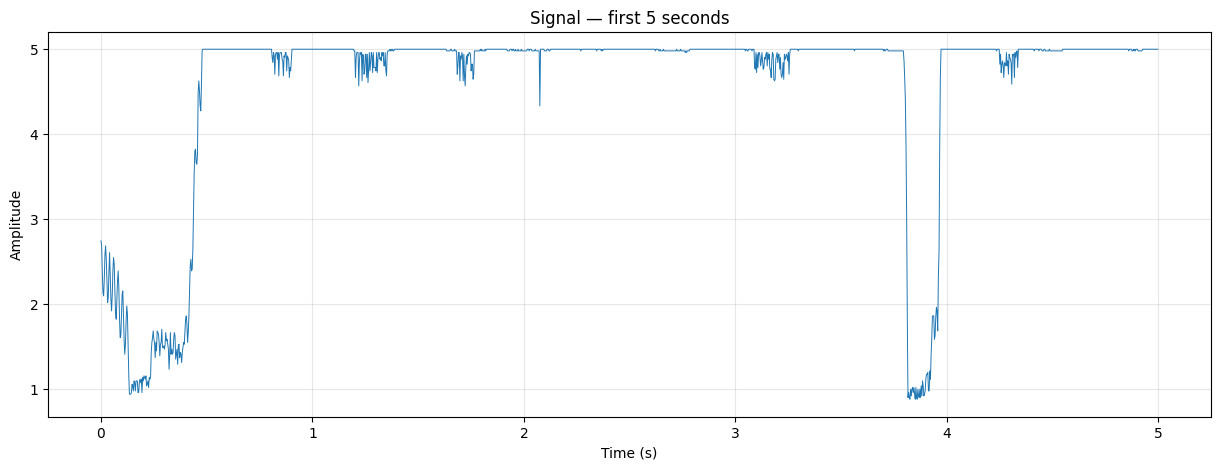


Statistics for Signal:
Duration: 303.9 s
Samples count: 97254
Minimum value: 0.5882
Maximum value: 5.0000
Mean value: 2.6779
Standard deviation: 1.5841


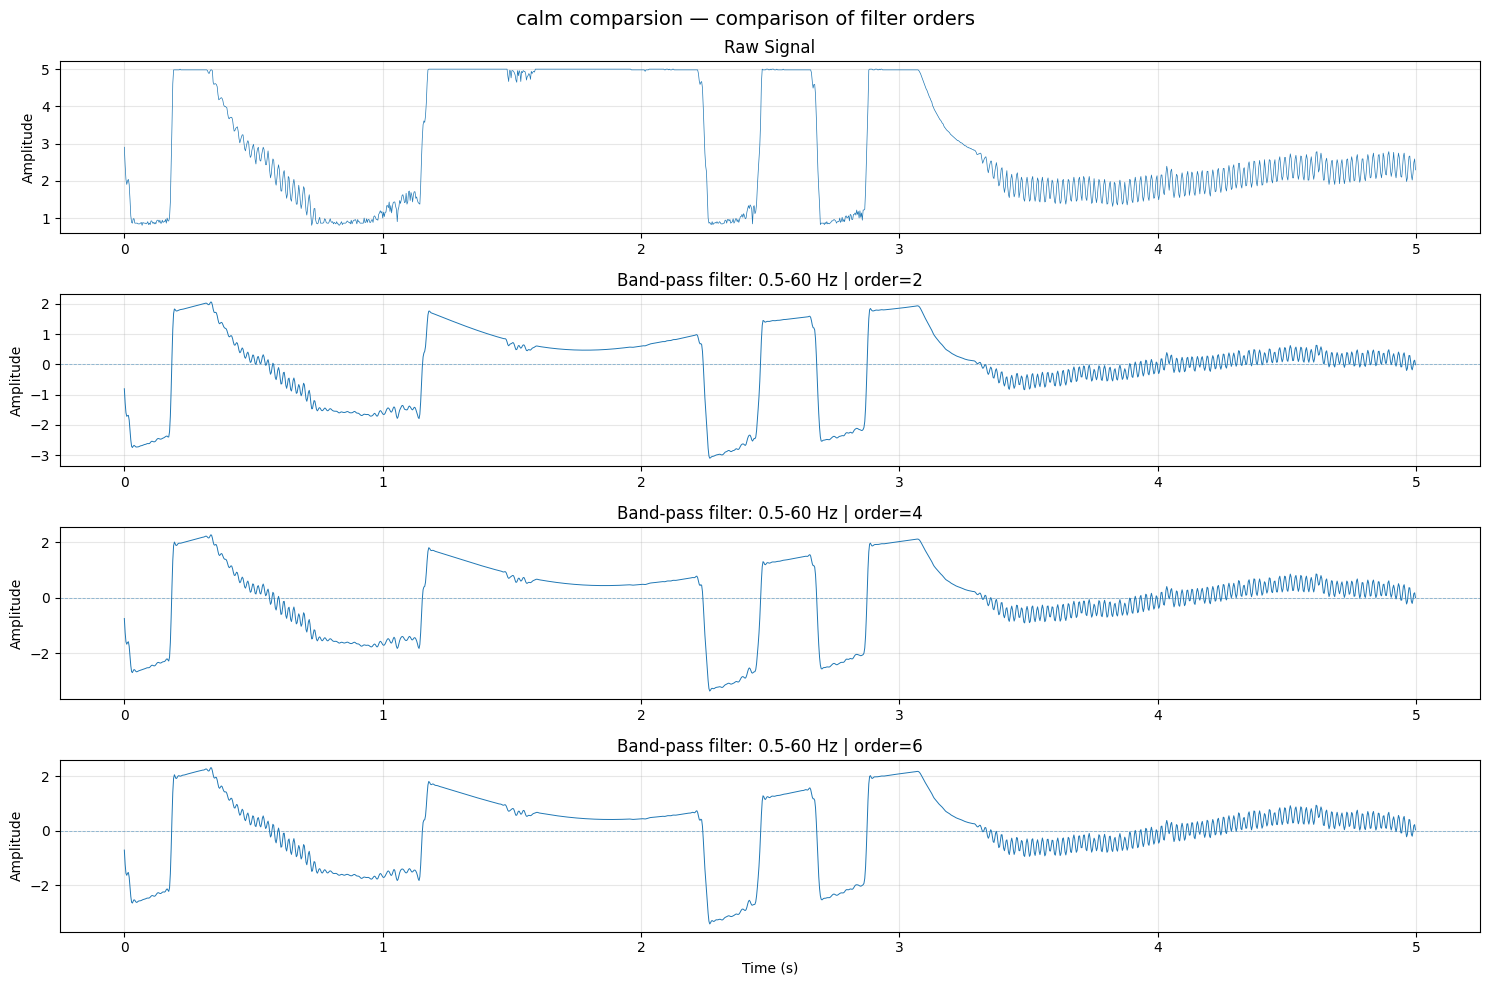


Filter comparison (0.5-60 Hz)
---------------------------------------------
Raw signal std: 1.5685
order=2: std=1.4935, mean=-0.0009
order=4: std=1.5015, mean=-0.0007
order=6: std=1.5030, mean=-0.0008


In [ ]:
visualize_signal(signals['run5_EEG.dat']['signal'], fs)

signal_1_run5 = crop_signal(signals['run5_EEG.dat']['signal'], fs, start_sec=10, end_sec=10)

compare_bandpass_filters(
    signal=signal_1_run5,
    fs=fs,
    filter_orders=[2, 4, 6],
    signal_name="calm comparsion"
)

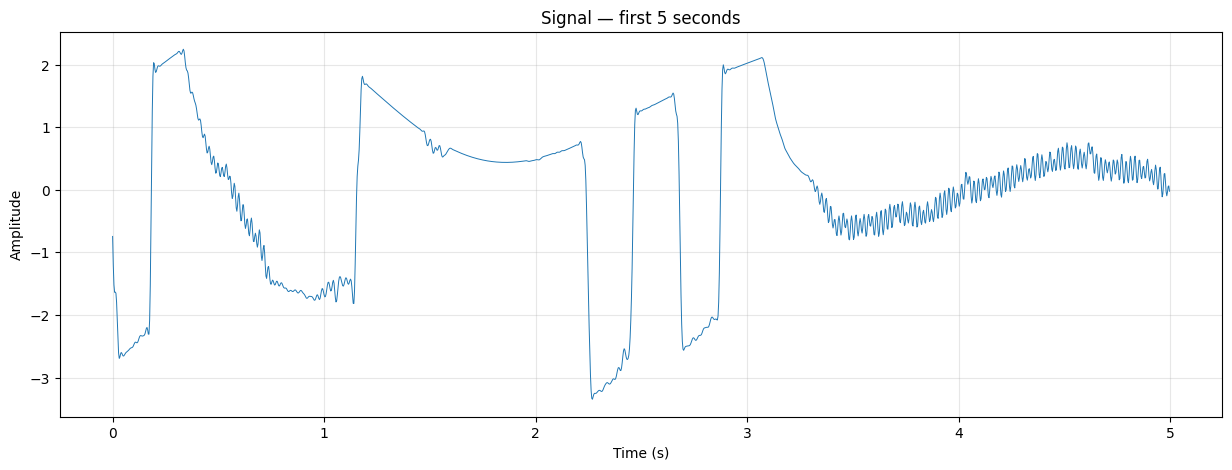


Statistics for Signal:
Duration: 283.9 s
Samples count: 90854
Minimum value: -3.3465
Maximum value: 2.8602
Mean value: -0.0007
Standard deviation: 1.4991


In [ ]:
signal_run5 = bandpass_filter(signal_1_run5, fs, order=4)
visualize_signal(signal_run5, fs)

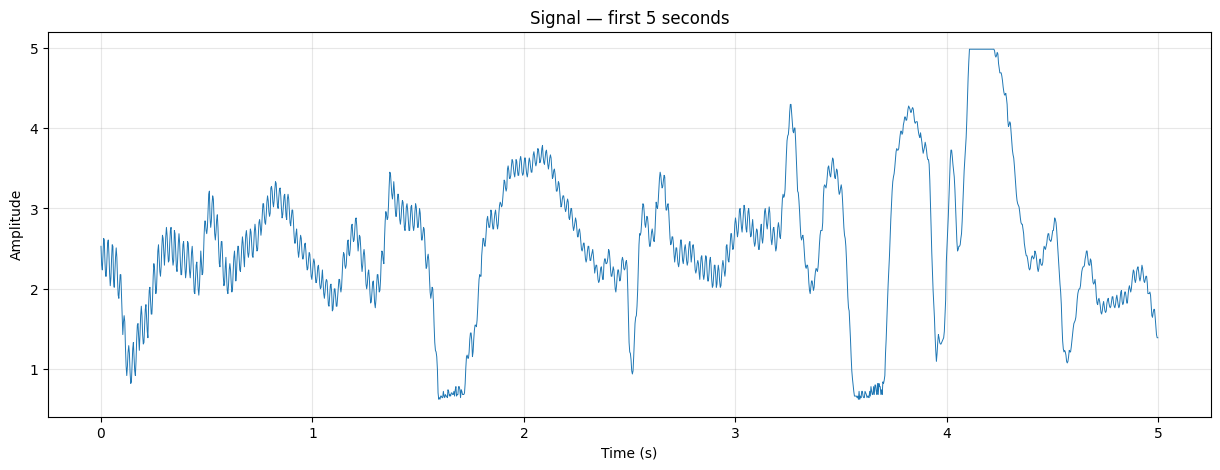


Statistics for Signal:
Duration: 322.8 s
Samples count: 103289
Minimum value: 0.6078
Maximum value: 4.9804
Mean value: 2.4529
Standard deviation: 0.2428


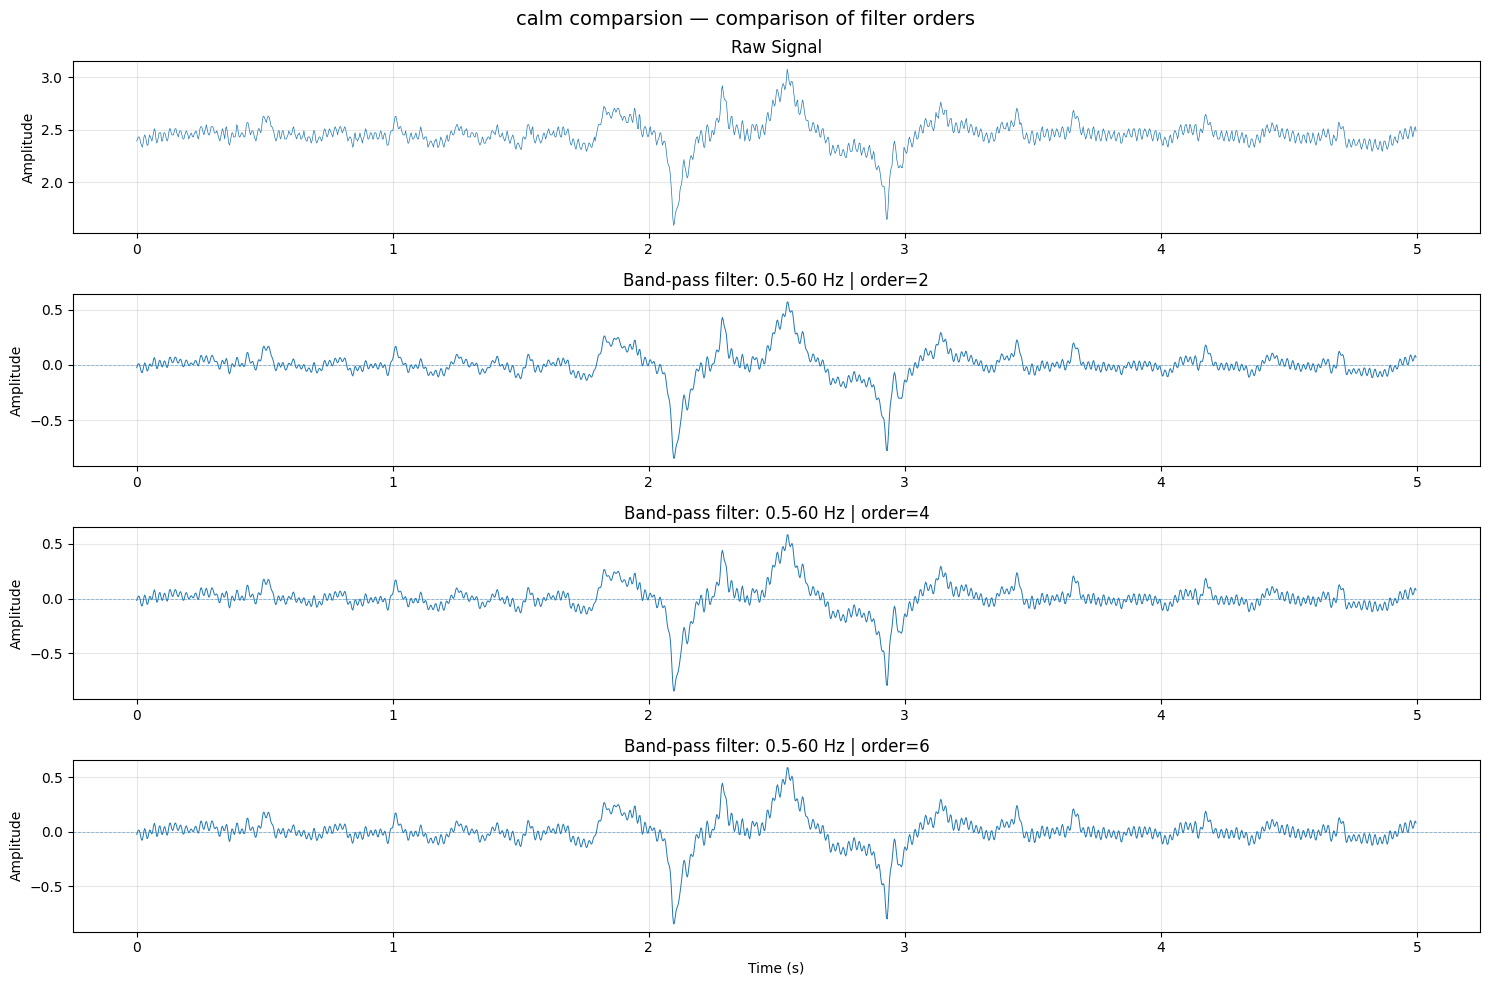


Filter comparison (0.5-60 Hz)
---------------------------------------------
Raw signal std: 0.1920
order=2: std=0.1626, mean=0.0000
order=4: std=0.1668, mean=0.0000
order=6: std=0.1683, mean=0.0000


In [ ]:
visualize_signal(signals['after_run5_EEG.dat']['signal'], fs)

signal_1_after_run5 = crop_signal(signals['after_run5_EEG.dat']['signal'], fs, start_sec=10, end_sec=10)

compare_bandpass_filters(
    signal=signal_1_after_run5,
    fs=fs,
    filter_orders=[2, 4, 6],
    signal_name="calm comparsion"
)

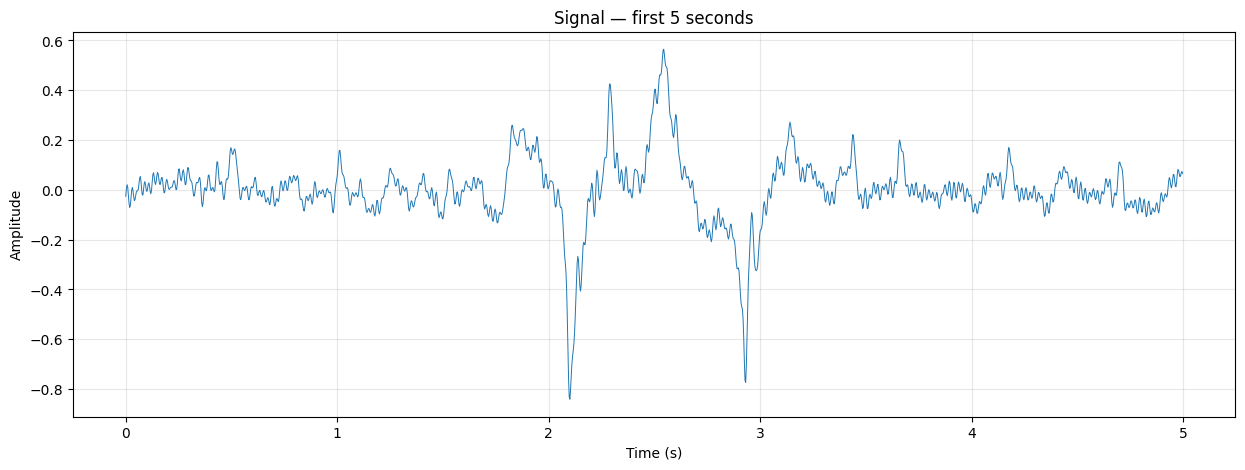


Statistics for Signal:
Duration: 302.8 s
Samples count: 96889
Minimum value: -1.8427
Maximum value: 2.6834
Mean value: 0.0000
Standard deviation: 0.1646


In [ ]:
signal_after_run5 = bandpass_filter(signal_1_after_run5, fs)
visualize_signal(signal_after_run5, fs)

## Анализ

In [ ]:
final_signals = {
    "calm": signal_calm,
    "walk": signal_walk,
    "run1": signal_run1,
    "after_run1": signal_after_run1,
    "run5": signal_run5,
    "after_run5": signal_after_run5
}

params = {
    'calm': {'min_distance_s': 0.2, 'prominence_factor': 0.5},
    'walk': {'min_distance_s': 0.2, 'prominence_factor': 0.5},
    'run1': {'min_distance_s': 0.2, 'prominence_factor': 0.5},
    'after_run1': {'min_distance_s': 0.2, 'prominence_factor': 0.5},
    'run5': {'min_distance_s': 0.2, 'prominence_factor': 0.5},
    'after_run5': {'min_distance_s': 0.2, 'prominence_factor': 0.5}
}

In [ ]:
def stress_index(rr_ms):
    rr = np.asarray(rr_ms)

    if len(rr) < 5:
        return np.nan

    mo = np.median(rr)
    mx_dm = np.max(rr) - np.min(rr)

    hist, bin_edges = np.histogram(rr, bins=10)
    amo = np.max(hist) / len(rr) * 100

    if mx_dm == 0 or mo == 0:
        return np.nan

    return amo / (2 * mo * mx_dm)


calm:
  R peaks: 1071
  Duration: 184.3 sec
  HR (total): 348.3 bpm
  HR (mean): 176.9 bpm
  SDNN: 31.4 ms
  RMSSD: 45.9 ms
  pNN50: 31.7 %
Индекс напряжения: 0.00029


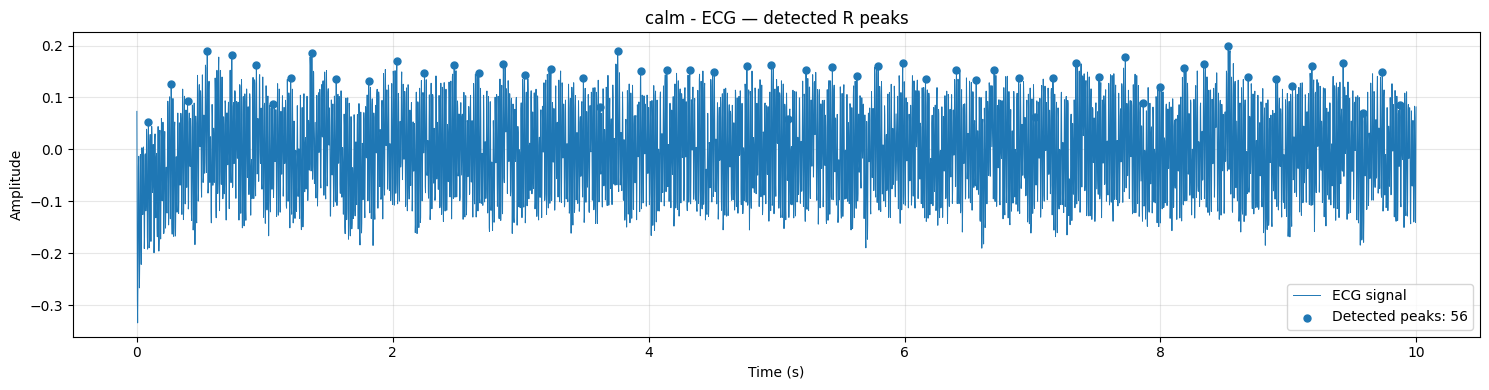

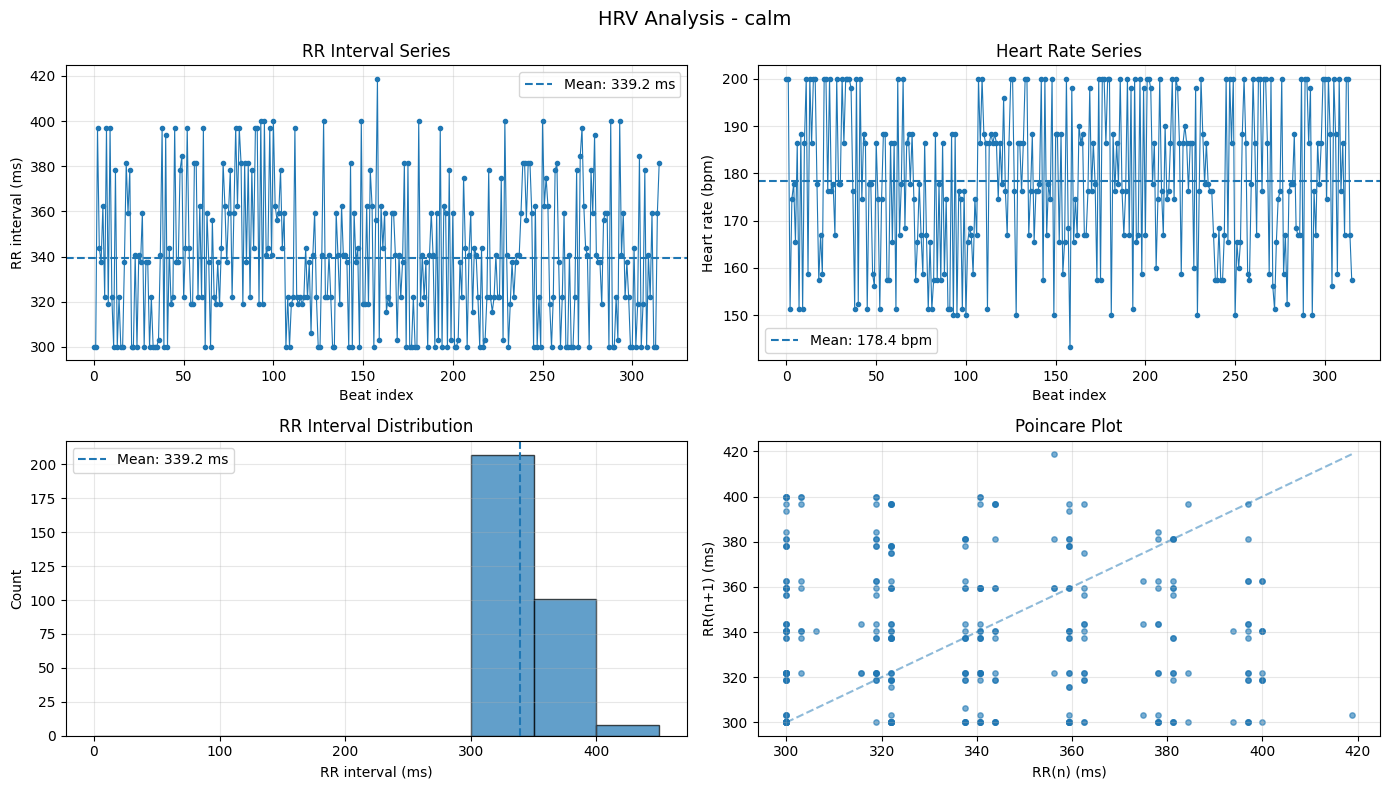


walk:
  R peaks: 530
  Duration: 183.0 sec
  HR (total): 173.4 bpm
  HR (mean): 118.7 bpm
  SDNN: 138.5 ms
  RMSSD: 175.2 ms
  pNN50: 57.9 %
Индекс напряжения: 0.00004


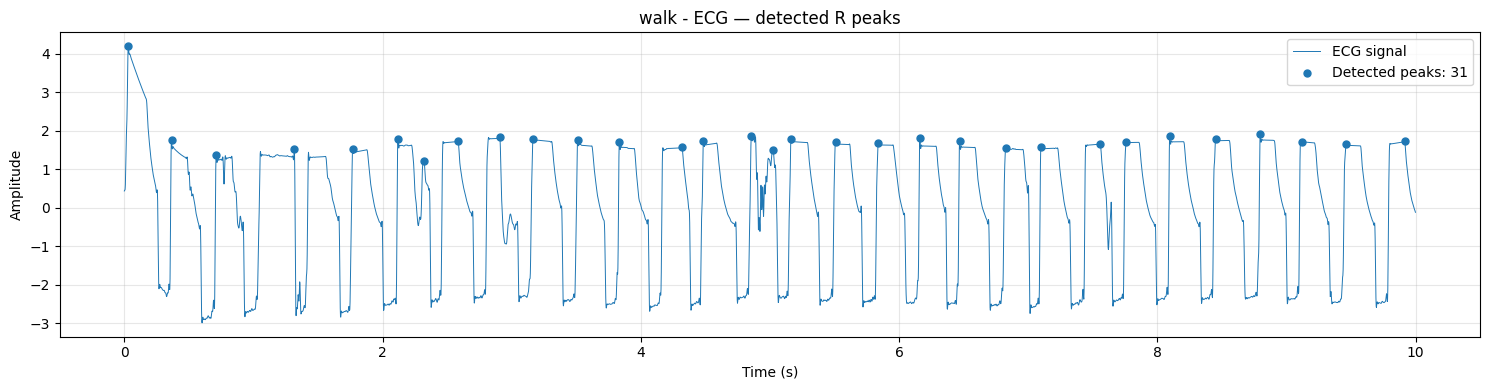

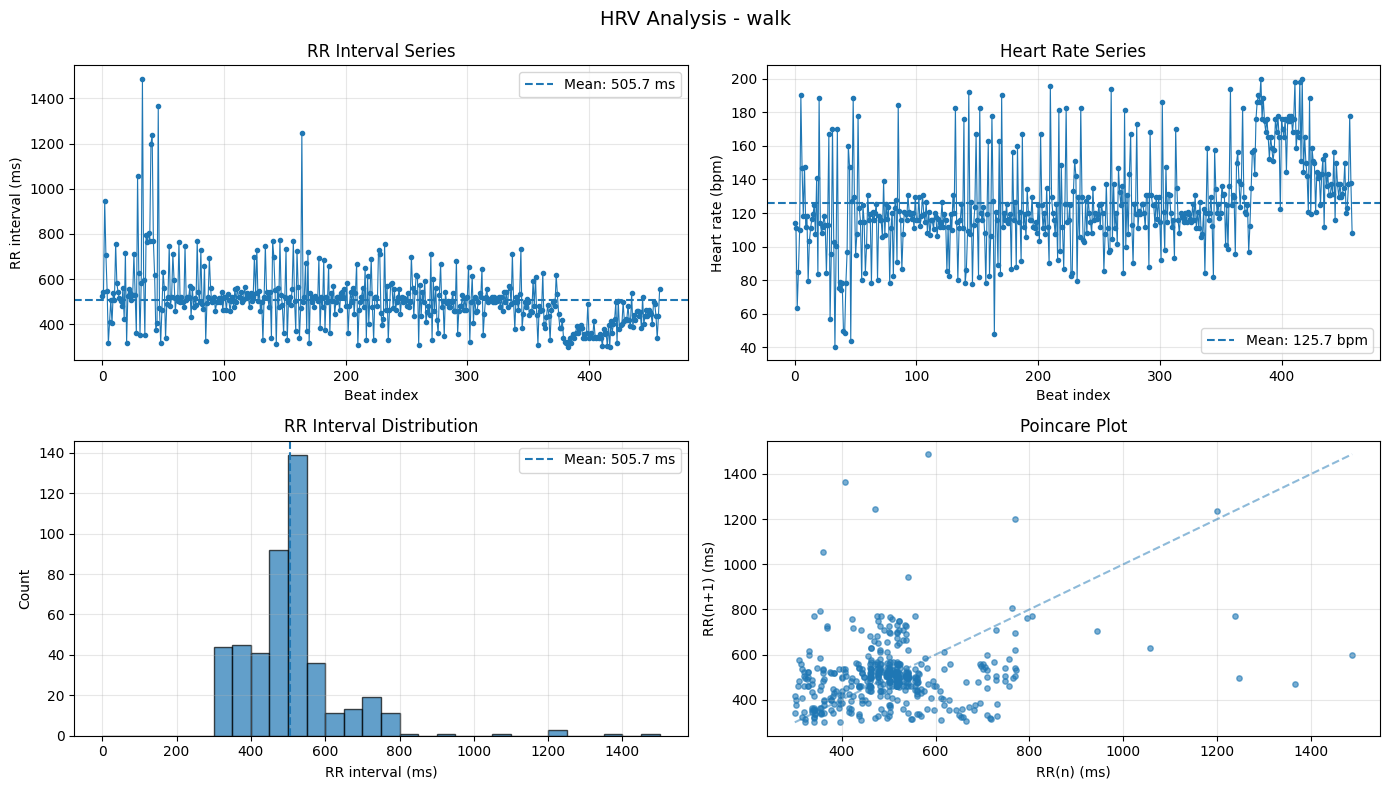


run1:
  R peaks: 104
  Duration: 27.2 sec
  HR (total): 226.8 bpm
  HR (mean): 140.9 bpm
  SDNN: 144.4 ms
  RMSSD: 190.9 ms
  pNN50: 51.2 %
Индекс напряжения: 0.00011


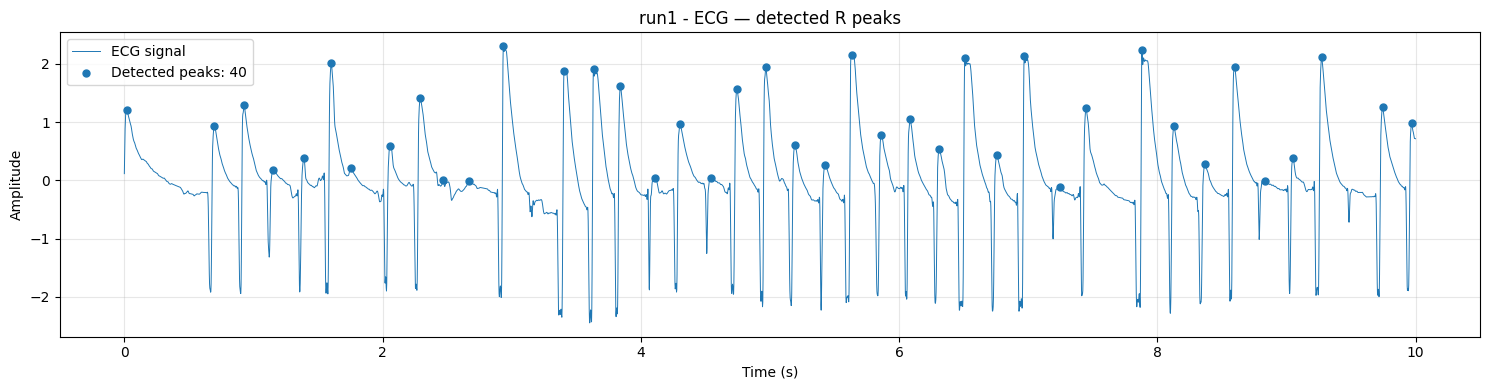

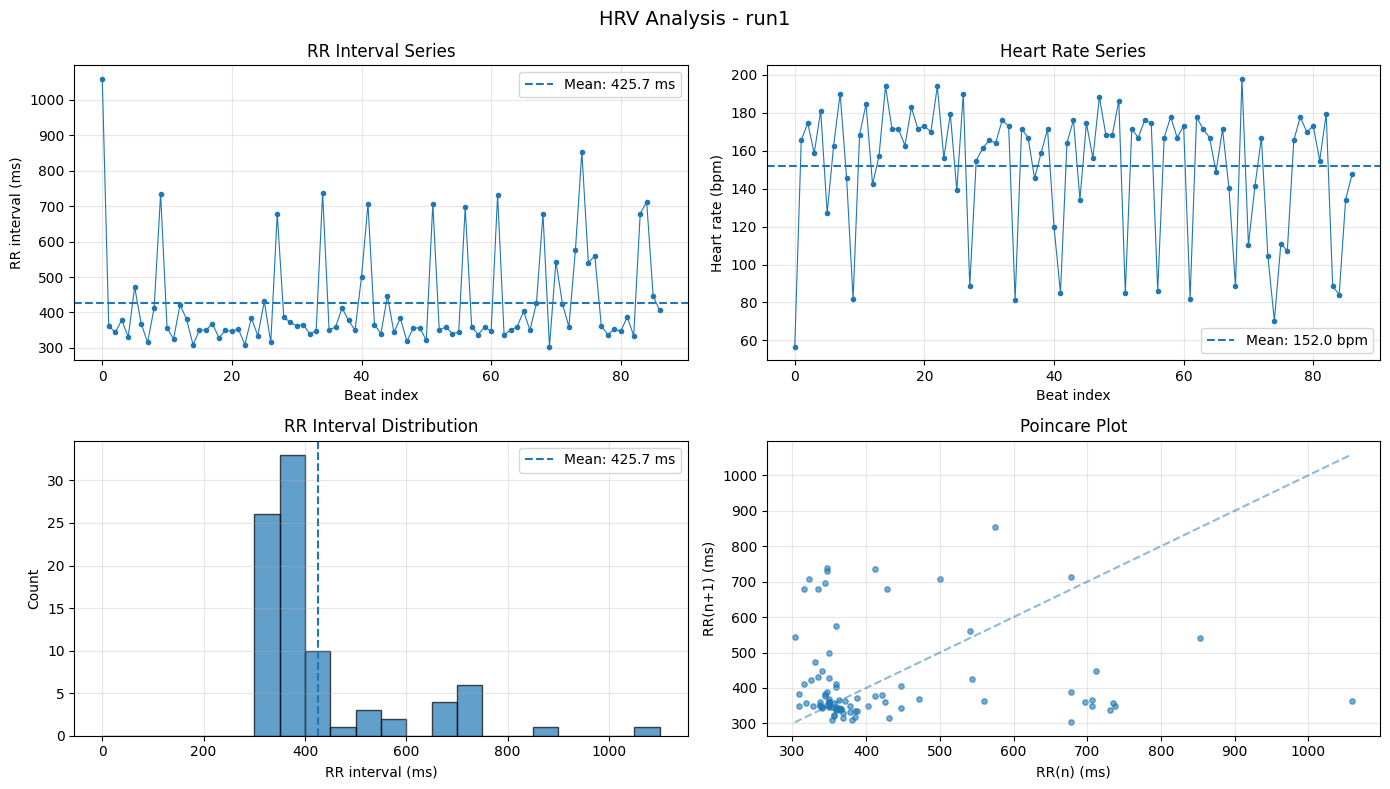


after_run1:
  R peaks: 729
  Duration: 211.7 sec
  HR (total): 206.4 bpm
  HR (mean): 116.0 bpm
  SDNN: 271.2 ms
  RMSSD: 362.2 ms
  pNN50: 72.5 %
Индекс напряжения: 0.00006


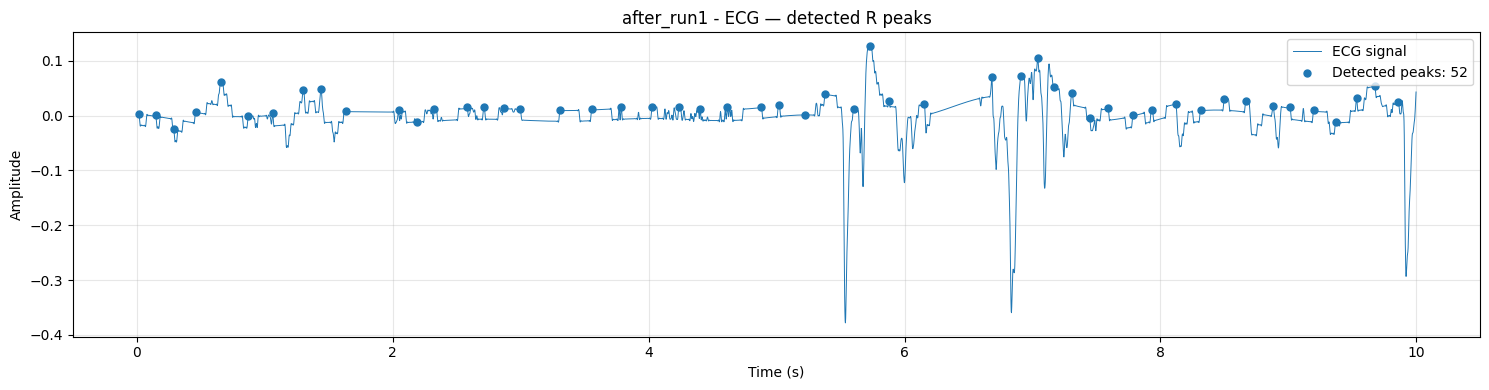

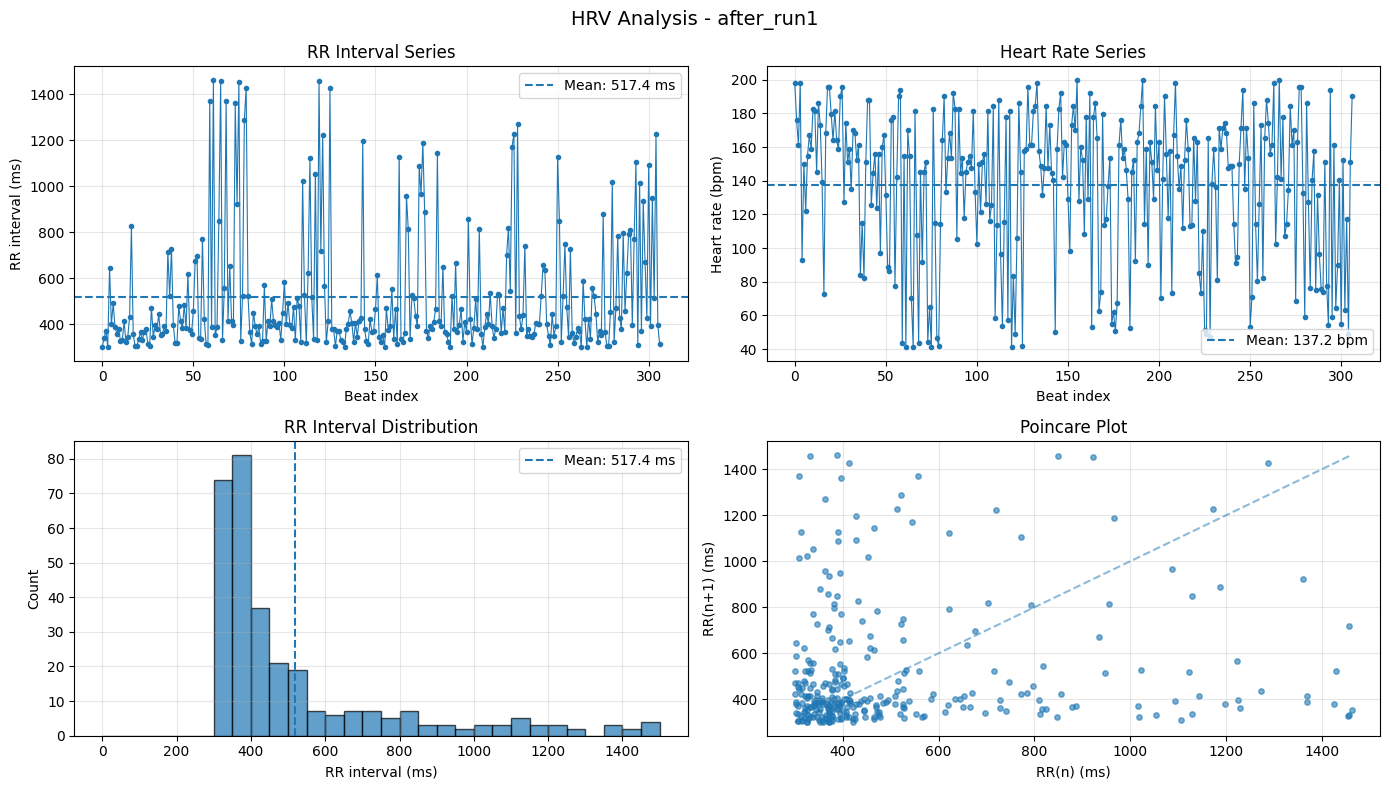


run5:
  R peaks: 720
  Duration: 181.7 sec
  HR (total): 237.4 bpm
  HR (mean): 146.3 bpm
  SDNN: 105.0 ms
  RMSSD: 130.1 ms
  pNN50: 52.5 %
Индекс напряжения: 0.00008


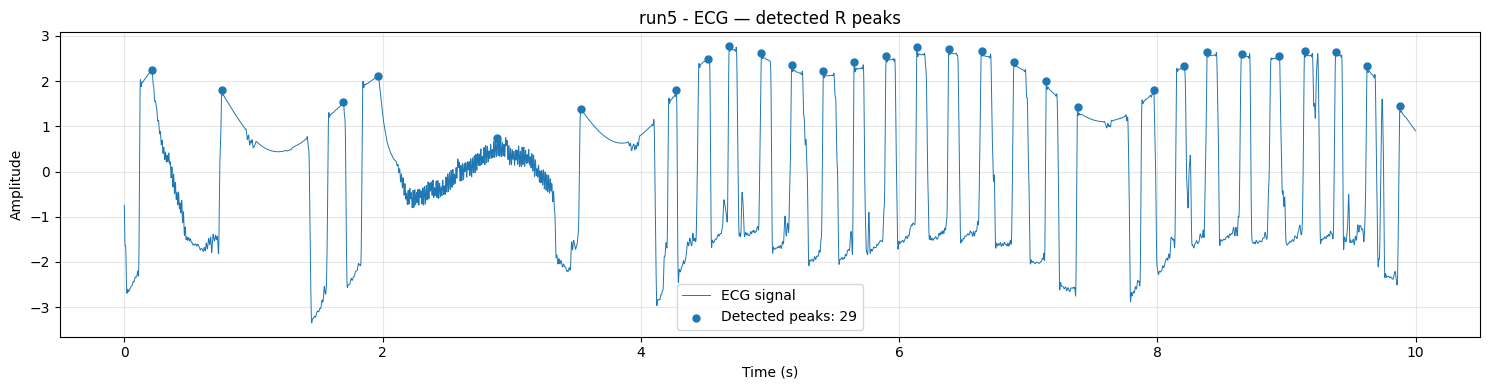

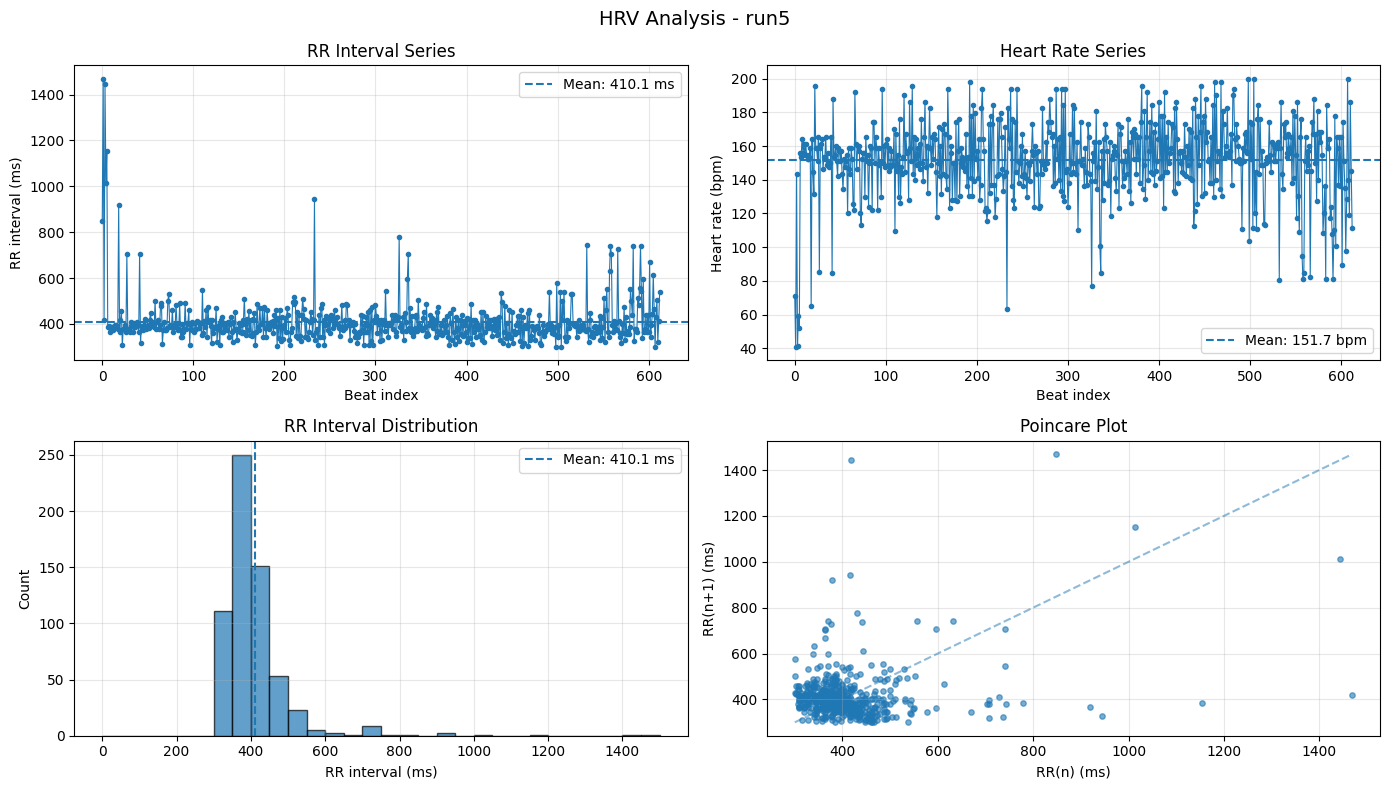


after_run5:
  R peaks: 1085
  Duration: 193.8 sec
  HR (total): 335.6 bpm
  HR (mean): 171.7 bpm
  SDNN: 30.4 ms
  RMSSD: 44.7 ms
  pNN50: 31.7 %
Индекс напряжения: 0.00021


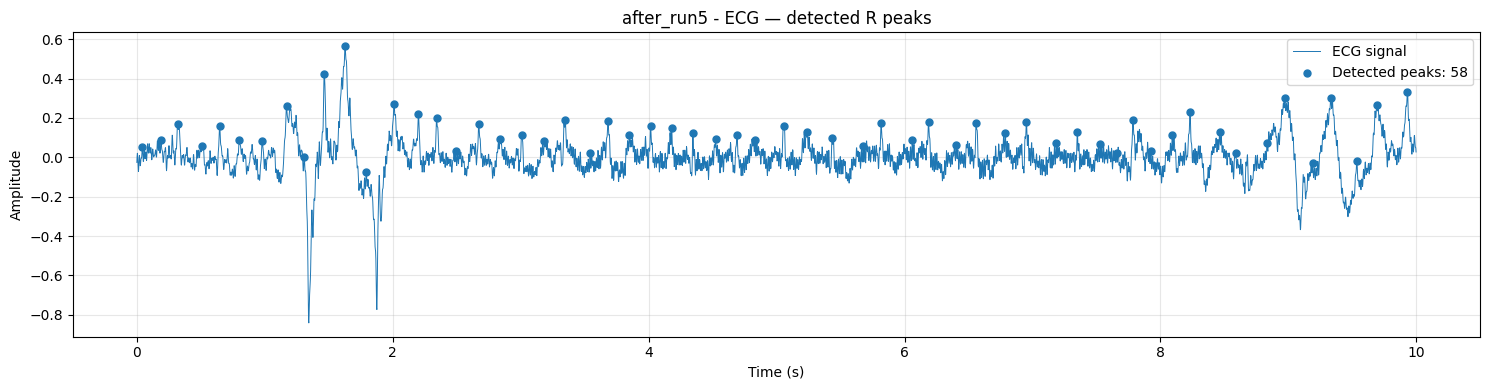

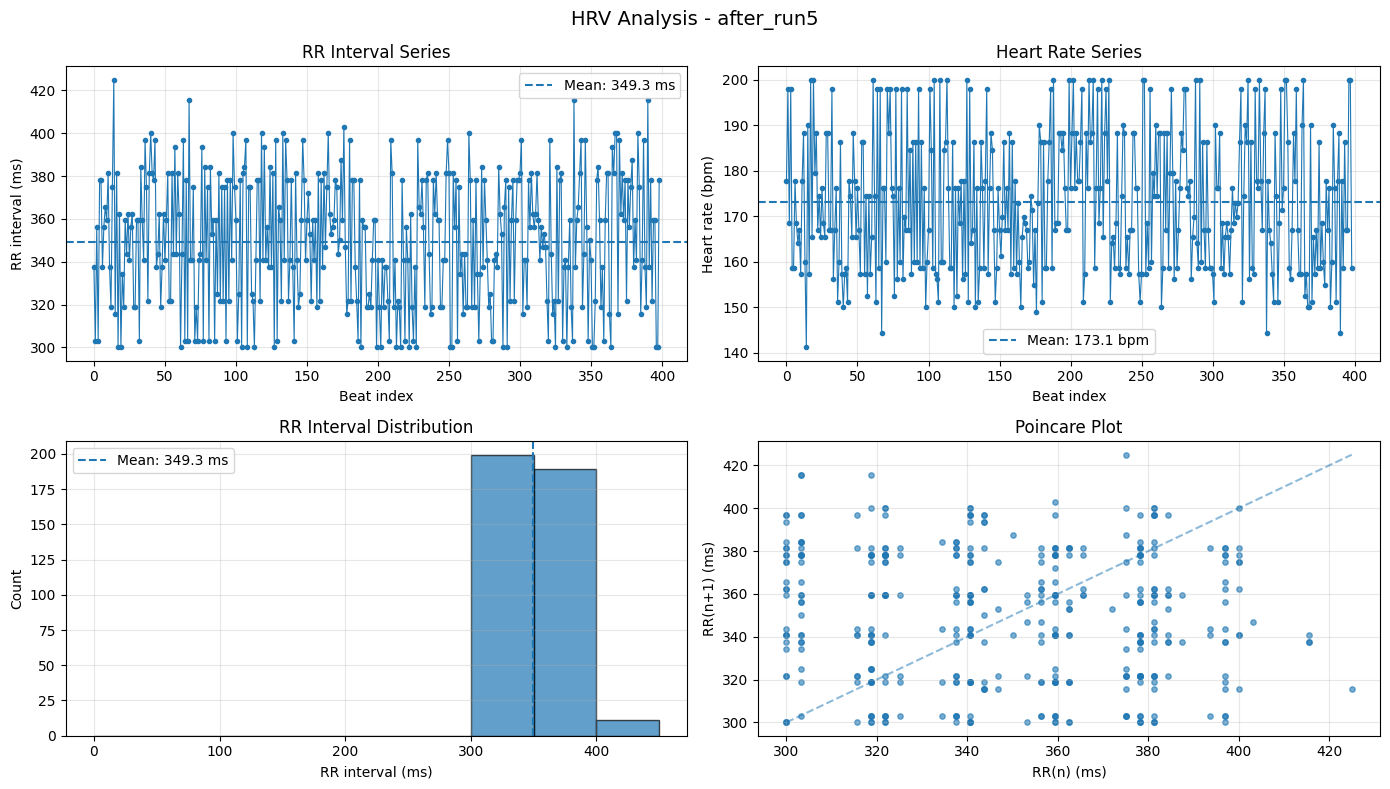

In [ ]:
results = {}

for name, signal in final_signals.items():
    p = params[name]

    # R - волна
    r_peaks, r_times = find_r_peaks(
        signal,
        fs,
        p['min_distance_s'],
        peak_threshold=0.3 * np.std(signal)
    )

    # HRV
    rr_ms, hr = compute_heart_rate(r_times)
    hrv = get_hrv_statistics(rr_ms)

    duration = len(signal) / 500
    hr_total = (len(r_peaks) - 1) / duration * 60
    si = stress_index(rr_ms)

    print(f"\n{name}:")
    print(f"  R peaks: {len(r_peaks)}")
    print(f"  Duration: {duration:.1f} sec")
    print(f"  HR (total): {hr_total:.1f} bpm")
    print(f"  HR (mean): {hrv['mean_hr_bpm']} bpm")
    print(f"  SDNN: {hrv['sdnn_ms']} ms")
    print(f"  RMSSD: {hrv['rmssd_ms']} ms")
    print(f"  pNN50: {hrv['pnn50_percent']} %")
    print(f"Индекс напряжения: {si:.5f}")

    results[name] = {
        'r_peaks': r_peaks,
        'rr_ms': rr_ms,
        'hrv': hrv
    }

    show_ecg_peaks(signal, r_peaks, fs=500, signal_name=f"{name} - ECG", duration_sec=10)
    show_hrv(rr_ms, hr, name=f"HRV Analysis - {name}")

In [ ]:
def plot_all_poincare(rr_dict):

    plt.figure(figsize=(10, 10))

    for name, rr in rr_dict.items():

        plt.scatter(
            rr[:-1],
            rr[1:],
            s=12,
            alpha=0.5,
            label=name
        )

    all_values = np.concatenate(list(rr_dict.values()))

    min_rr = np.min(all_values)
    max_rr = np.max(all_values)

    plt.plot(
        [min_rr, max_rr],
        [min_rr, max_rr],
        'k--',
        alpha=0.5
    )

    plt.title("Poincare Plots Comparison")

    plt.xlabel("RR(n) (ms)")
    plt.ylabel("RR(n+1) (ms)")

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.show()

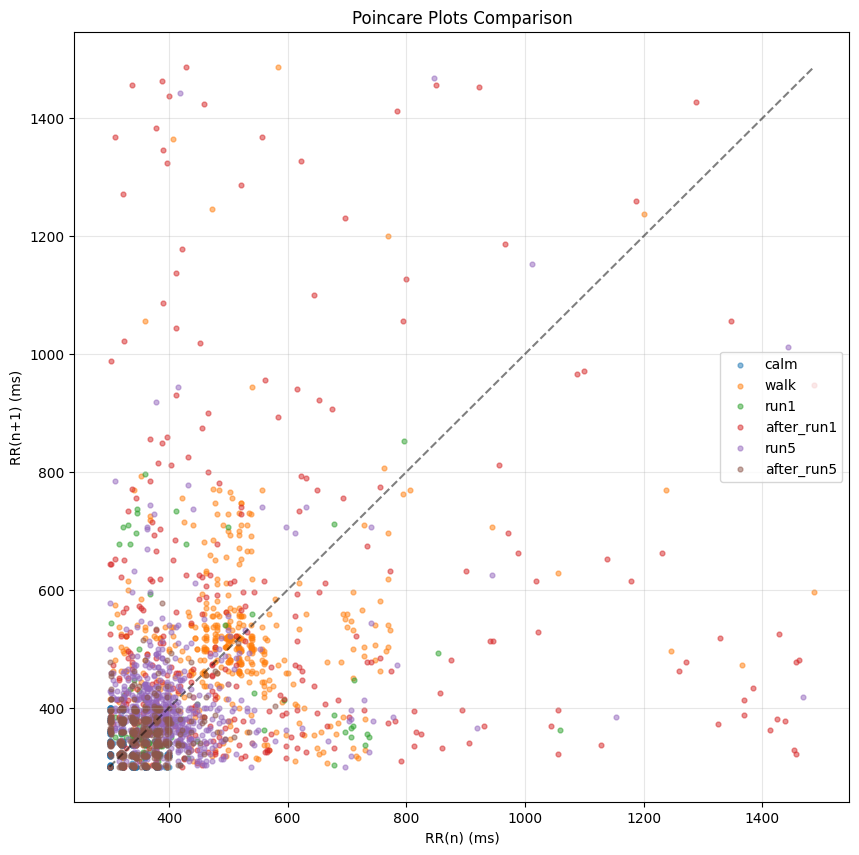

In [ ]:
rr_data = {
    "calm": results['calm']['rr_ms'],
    "walk": results['walk']['rr_ms'],
    "run1": results['run1']['rr_ms'],
    "after_run1": results['after_run1']['rr_ms'],
    "run5": results['run5']['rr_ms'],
    "after_run5": results['after_run5']['rr_ms']
}

plot_all_poincare(rr_data)

     State  HR (bpm)  SDNN (ms)  RMSSD (ms)  pNN50 (%)
      calm     176.9       31.4        45.9       31.7
      walk     118.7      138.5       175.2       57.9
      run1     138.0      151.6       201.7       50.6
after_run1     104.9      282.2       391.9       84.4
      run5     145.6      106.9       130.9       52.2
after_run5     167.8       41.5        55.4       37.4


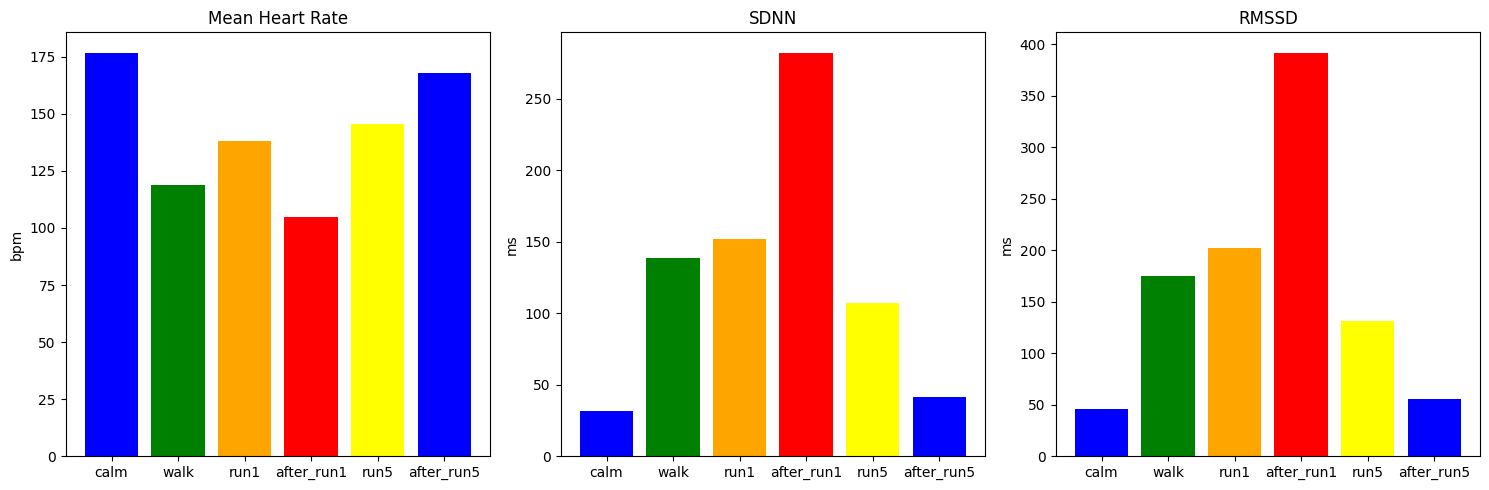

In [ ]:
import pandas as pd

summary = []
for name, res in results.items():
    hrv = res['hrv']
    summary.append({
        'State': name,
        'HR (bpm)': hrv['mean_hr_bpm'],
        'SDNN (ms)': hrv['sdnn_ms'],
        'RMSSD (ms)': hrv['rmssd_ms'],
        'pNN50 (%)': hrv['pnn50_percent']
    })

summary_df = pd.DataFrame(summary)

print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
states = summary_df['State'].values

axes[0].bar(states, summary_df['HR (bpm)'], color=['blue', 'green', 'orange', 'red', 'yellow'])
axes[0].set_title('Mean Heart Rate')
axes[0].set_ylabel('bpm')

axes[1].bar(states, summary_df['SDNN (ms)'], color=['blue', 'green', 'orange', 'red', 'yellow'])
axes[1].set_title('SDNN')
axes[1].set_ylabel('ms')

axes[2].bar(states, summary_df['RMSSD (ms)'], color=['blue', 'green', 'orange', 'red', 'yellow'])
axes[2].set_title('RMSSD')
axes[2].set_ylabel('ms')

plt.tight_layout()
plt.show()

## Вывод


По результатам анализа можно сделать вывод, что физическая активность заметно повлияла на показатели сердечного ритма и его вариабельности.

В состоянии покоя средняя частота сердечных сокращений составила 87.9 bpm. Показатели вариабельности сердечного ритма (SDNN = 158.8 мс, RMSSD = 212.4 мс, pNN50 = 74.9%) свидетельствуют о достаточно высокой вариабельности ритма и стабильной работе вегетативной нервной системы.

Во время ходьбы наблюдалось снижение средней ЧСС до 78.8 bpm, однако показатели вариабельности значительно увеличились (SDNN = 271.9 мс, RMSSD = 398.0 мс). Это может быть связано с выраженными двигательными артефактами и изменением характера сердечного ритма при физической активности.

При беге в течение 1 минуты и 5 минут вариабельность сердечного ритма уменьшалась по сравнению с ходьбой, а значения pNN50 также снижались. Это соответствует повышению нагрузки на сердечно-сосудистую систему.

После нагрузки наблюдалось восстановление показателей. После короткого бега значения SDNN, RMSSD и pNN50 вновь увеличились, что указывает на восстановление регуляции сердечного ритма. Однако после более длительного бега показатели вариабельности оказались минимальными (SDNN = 131.3 мс, RMSSD = 165.8 мс, pNN50 = 35.2%), а ЧСС возросла до 85.9 bpm. Это свидетельствует о более выраженном утомлении организма и неполном восстановлении после продолжительной нагрузки.

Таким образом, результаты показывают, что увеличение физической нагрузки приводит к изменению частоты сердечных сокращений и снижению вариабельности сердечного ритма, а длительная нагрузка требует большего времени для восстановления сердечно-сосудистой системы.

